In [1]:
# ---------- imports & environment ----------
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import sys, re, glob, time, html, shutil, zipfile, tarfile, subprocess, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
from IPython.display import display, HTML
from tqdm.auto import tqdm

layers = keras.layers
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
tf.get_logger().setLevel("ERROR")

ON_KAGGLE = os.path.exists("/kaggle/working")
ON_COLAB = "google.colab" in sys.modules
BASE_DIR = Path("/kaggle/working") if ON_KAGGLE else (Path("/content") if ON_COLAB else Path("."))
DATA_DIR, OUT_DIR = BASE_DIR / "data", BASE_DIR / "outputs"
PLOT_DIR, TABLE_DIR = OUT_DIR / "plots", OUT_DIR / "tables"
for d in (DATA_DIR, PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", [g.name for g in gpus] if gpus else "none -> running on CPU (works, just slower)")
print("Outputs will be written to:", OUT_DIR.resolve())

TensorFlow 2.20.0 | Keras 3.13.2
GPU: ['/physical_device:GPU:0']
Outputs will be written to: /content/outputs


In [2]:
np.random.seed(42)
tf.random.set_seed(42)
keras.utils.set_random_seed(42)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Set all text weights and sizes to 14 Bold globally
plt.rcParams['font.size'] = 14
plt.rcParams['font.weight'] = 'bold'

# Ensure individual components inherit the bold styling and size
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

# Apply bold to axis tick numbers
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

In [3]:
# ---------- global configuration (same values for every model => controlled comparison) ----------
SEED = 42

# --- HAR (sequence classification) ---
USE_FULL_DATA = False        # False: class-balanced subset of the training partition (lab-friendly); True: all 10,299 windows
N_SUBSET      = 3000         # windows used when USE_FULL_DATA=False (manual recommends 1500-3000)
SPLIT_MODE    = "subject"    # "subject": no subject appears in two splits (recommended: HAR windows overlap 50%, so a random
                             #            window split leaks neighbours into val/test) | "stratified": random stratified windows
SEQ_LEN, N_FEATURES, N_CLASSES = 128, 9, 6
UNITS, DROPOUT, LR, BATCH, EPOCHS = 32, 0.2, 1e-3, 32, 30
SEQ_LENGTHS = [32, 64, 128]

# --- Video (CNN + RNN) ---
N_FRAMES, IMG_SIZE = 10, 224
N_VIDEO_CLASSES, MAX_VIDEOS_PER_CLASS = 5, 40
VIDEO_SOURCE = "auto"        # "auto": Hugging Face UCF101 subset (small, fast) | "official": UCF101.rar from crcv.ucf.edu (~6.5 GB)
VID_UNITS, VID_EPOCHS, VID_BATCH, VID_DROPOUT = 32, 40, 16, 0.3

# --- Sequence-to-sequence (reversal) ---
S2S_LEN, S2S_MAX_INT, S2S_N = 6, 9, 12000     # length-6 sequences over the integers 1..9 (12,000 unique sequences)
S2S_UNITS, S2S_EMB, S2S_EPOCHS, S2S_BATCH = 128, 32, 60, 128

RUN_ADDITIONAL_EXERCISES = True   # Section 28 (extra trainings). Set True to run them.

CLASS_NAMES  = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
CLASS_LABELS = [n.replace("_", " ").title() for n in CLASS_NAMES]
SIGNALS = ["body_acc_x", "body_acc_y", "body_acc_z", "body_gyro_x", "body_gyro_y", "body_gyro_z",
           "total_acc_x", "total_acc_y", "total_acc_z"]
MODELS = ["RNN", "LSTM", "GRU"]
COLORS = {"RNN": "tab:red", "LSTM": "tab:blue", "GRU": "tab:green"}

In [4]:
# ---------- helpers: saving, inference boxes, callbacks, metrics, diagnostics ----------
def save_fig(fig, name):
    path = PLOT_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"[saved] {path}")

def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path)
    print(f"[saved] {path}")

INFERENCE_LOG = []
def inference(tag, line1, line2=None):
    """Render a boxed inference (max 2 lines) and log it for Section 26 / inferences.txt."""
    lines = [line1] + ([line2] if line2 else [])
    INFERENCE_LOG.append((tag, " ".join(lines)))
    body = "<br>".join(html.escape(l) for l in lines)
    display(HTML('<div style="background:#eef6ff;border-left:5px solid #1f77b4;padding:8px 14px;margin:6px 0 16px 0;'
                 'color:#0b1f33;font-size:13px;line-height:1.5"><b>Inference:</b> ' + body + '</div>'))

def set_seed(seed=SEED):
    keras.utils.set_random_seed(seed)

def count_params(model):
    return int(sum(np.prod(tuple(w.shape)) for w in model.trainable_weights))

class RestoreBest(keras.callbacks.Callback):
    """Keeps the weights of the epoch with the lowest VALIDATION loss and restores them after training
    (model selection uses the validation set only - the test set is never touched)."""
    def __init__(self):
        super().__init__(); self.best, self.weights, self.epoch = np.inf, None, 0
    def on_epoch_end(self, epoch, logs=None):
        v = (logs or {}).get("val_loss")
        if v is not None and v < self.best:
            self.best, self.weights, self.epoch = v, self.model.get_weights(), epoch + 1
    def on_train_end(self, logs=None):
        if self.weights is not None:
            self.model.set_weights(self.weights)

class EpochPrinter(keras.callbacks.Callback):
    def __init__(self, every=5):
        super().__init__(); self.every = every
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        if epoch == 0 or (epoch + 1) % self.every == 0:
            print(f"   epoch {epoch+1:>3} | loss {logs.get('loss', float('nan')):.4f}  acc {logs.get('accuracy', float('nan'))*100:5.1f}%"
                  f" | val_loss {logs.get('val_loss', float('nan')):.4f}  val_acc {logs.get('val_accuracy', float('nan'))*100:5.1f}%")

def evaluate_classifier(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return dict(accuracy=accuracy_score(y_true, y_pred) * 100, precision=p * 100, recall=r * 100, f1=f * 100)

# ----- training-curve diagnostics (drive the auto-generated inferences) -----
def curve_facts(h):
    tl, vl = np.array(h["loss"]), np.array(h["val_loss"])
    ta, va = np.array(h["accuracy"]) * 100, np.array(h["val_accuracy"]) * 100
    be = int(vl.argmin())
    return dict(E=len(tl), best_ep=be + 1, conv_ep=int(np.argmax(vl <= vl.min() * 1.05)) + 1,
                tl0=tl[0], tl_end=tl[-1], vl_min=vl[be], vl_end=vl[-1],
                ta_end=ta[-1], va_end=va[-1], va_best=va.max(), gap=ta[-1] - va[-1])

def diagnose(f):
    if f["ta_end"] < 70 and f["va_end"] < 70: return "under"
    if f["gap"] > 8 or (f["vl_end"] > 1.2 * f["vl_min"] and f["gap"] > 4): return "over"
    if f["best_ep"] >= f["E"] - 2: return "still"
    return "good"

STATUS_TXT = {"under": "Underfitting / slow convergence", "over": "Overfitting", "still": "Still converging",
              "good": "Converged, small generalisation gap"}
CONCL_TXT = {"under": "Low train and val scores → limited by optimisation/capacity.",
             "over":  "Train ≫ val → memorisation; needs regularisation or more data.",
             "still": "Curves still improving → more epochs would likely help.",
             "good":  "Train and val track each other → generalises to unseen data."}

def loss_inference(tag, name, h, reason):
    f = curve_facts(h)
    inference(tag,
        f"{name}: train loss {f['tl0']:.2f}→{f['tl_end']:.2f}; val loss min {f['vl_min']:.2f} (epoch {f['best_ep']}/{f['E']}), within 5% of it from epoch {f['conv_ep']}.",
        f"{STATUS_TXT[diagnose(f)]} — {reason}.")

def acc_inference(tag, name, h):
    f = curve_facts(h)
    inference(tag,
        f"{name}: final train/val accuracy {f['ta_end']:.1f}/{f['va_end']:.1f}% (best val {f['va_best']:.1f}%); gap {f['gap']:+.1f} pts.",
        CONCL_TXT[diagnose(f)])

def plot_training_curves(h, best_ep, name, metric, fname):
    scale = 100 if metric == "accuracy" else 1
    ep = np.arange(1, len(h[metric]) + 1)
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.plot(ep, np.array(h[metric]) * scale, color="tab:blue", lw=2.5, label="Training")
    ax.plot(ep, np.array(h["val_" + metric]) * scale, color="tab:orange", lw=2.5, ls="--", label="Validation")
    ax.axvline(best_ep, color="gray", ls=":", lw=2, label=f"Best val-loss epoch ({best_ep})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss" if metric == "loss" else "Accuracy (%)")
    ax.set_title(f"{name}: Training vs Validation " + ("Loss" if metric == "loss" else "Accuracy"))
    ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); save_fig(fig, fname); plt.show()

# ----- confusion-matrix utilities -----
def plot_confusion(cm, labels, title, fname, cmap="Blues"):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(9.5, 8))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_yticklabels(labels)
    thr = cm.max() / 2 if cm.max() > 0 else 1
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > thr else "black")
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label"); ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout(); save_fig(fig, fname); plt.show()

def cm_facts(cm, labels):
    n = cm.sum(axis=1); rec = np.diag(cm) / np.maximum(n, 1) * 100; err = n - np.diag(cm)
    off = cm.copy(); np.fill_diagonal(off, 0); pair = off + off.T
    iu = np.triu_indices_from(pair, k=1); k = int(pair[iu].argmax()); a, b = int(iu[0][k]), int(iu[1][k])
    bi, wi = int(rec.argmax()), int(err.argmax())
    return dict(best=labels[bi], best_rec=rec[bi], worst=labels[wi], worst_err=int(err[wi]), worst_rec=rec[wi],
                pair=(labels[a], labels[b]), pair_ids=(a, b), pair_n=int(pair[a, b]), total_err=int(err.sum()))

def har_pair_why(a, b):
    if a >= 3 and b >= 3: return "both near-static postures"
    if a < 3 and b < 3:   return "similar gait cycles"
    return "overlapping signal statistics"

def cm_inference(tag, name, cm, labels, why_fn=None):
    f = cm_facts(cm, labels)
    l1 = f"{name}: best class {f['best']} ({f['best_rec']:.0f}%); most errors {f['worst']} ({f['worst_err']}, recall {f['worst_rec']:.0f}%)."
    if f["pair_n"] > 0:
        why = f" — {why_fn(*f['pair_ids'])}" if why_fn else ""
        l2 = f"Top confusion: {f['pair'][0]} ↔ {f['pair'][1]} ({f['pair_n']} samples){why}."
    else:
        l2 = "No confusions between any pair of classes on this test set."
    inference(tag, l1, l2)
    return f

## 3. Dataset

In [5]:
# ===== 3. Download / locate the UCI HAR raw inertial signals =====
HAR_URLS = ["https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
            "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"]

def download(url, dest, verify=True, chunk=1 << 20):
    import requests
    with requests.get(url, stream=True, timeout=120, verify=verify) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for c in r.iter_content(chunk):
                f.write(c)
    return dest

def find_har_root():
    for base in (str(DATA_DIR), "/kaggle/input", "."):
        for p in glob.glob(os.path.join(base, "**", "Inertial Signals"), recursive=True):
            root = os.path.dirname(os.path.dirname(p))             # <root>/train/Inertial Signals -> <root>
            if os.path.isfile(os.path.join(root, "train", "y_train.txt")) and os.path.isfile(os.path.join(root, "test", "y_test.txt")):
                return root
    return None

def prepare_har():
    root = find_har_root()
    if root:
        return root
    zpath = DATA_DIR / "har.zip"
    for url in HAR_URLS:
        try:
            print("Downloading", url)
            download(url, zpath)
            if zipfile.is_zipfile(zpath):
                break
        except Exception as e:
            print("   failed:", e)
    else:
        raise RuntimeError("Could not download UCI HAR. On Kaggle enable Internet, or attach a UCI-HAR dataset to the notebook "
                           "(Add data -> search 'UCI HAR'); on Colab upload the extracted 'UCI HAR Dataset' folder to /content/data.")
    with zipfile.ZipFile(zpath) as z:
        z.extractall(DATA_DIR / "har")
    for inner in glob.glob(str(DATA_DIR / "har" / "**" / "*.zip"), recursive=True):   # the UCI archive nests a second zip
        if zipfile.is_zipfile(inner):
            with zipfile.ZipFile(inner) as z:
                z.extractall(DATA_DIR / "har")
    root = find_har_root()
    if root is None:
        raise RuntimeError("UCI HAR folder structure not found after extraction.")
    return root

def load_split(root, split):
    """-> X (N,128,9) float32, y (N,) in 0..5, subject ids (N,)"""
    chans = []
    for s in SIGNALS:
        f = os.path.join(root, split, "Inertial Signals", f"{s}_{split}.txt")
        chans.append(pd.read_csv(f, sep=r"\s+", header=None).values.astype(np.float32))      # (N,128)
    X = np.stack(chans, axis=-1)                                                              # (N,128,9)
    y = pd.read_csv(os.path.join(root, split, f"y_{split}.txt"), header=None).values.ravel().astype(int) - 1
    subj = pd.read_csv(os.path.join(root, split, f"subject_{split}.txt"), header=None).values.ravel().astype(int)
    return X, y, subj

HAR_ROOT = prepare_har()
print("UCI HAR found at:", HAR_ROOT)

UCI HAR found at: /content/data/har/UCI HAR Dataset


## 5. Preprocessing

In [6]:
# ===== 5. Preprocessing =====
def balanced_subset(y, n_total):
    """Class-balanced, evenly spaced (covers all subjects) subset of indices."""
    if n_total is None:
        return np.arange(len(y))
    per_class, idx = n_total // N_CLASSES, []
    for c in range(N_CLASSES):
        ci = np.where(y == c)[0]
        take = min(per_class, len(ci))
        idx.append(ci[np.unique(np.linspace(0, len(ci) - 1, take).round().astype(int))])
    return np.sort(np.concatenate(idx))

def subject_split(subj, y, fracs=(0.70, 0.15, 0.15), seed=SEED, tries=200):
    """Assign whole subjects to train/val/test so that window proportions are as close to 70/15/15 as possible."""
    n, subs_all = len(subj), np.unique(subj)
    counts = {s: int((subj == s).sum()) for s in subs_all}
    for t in range(tries):
        rng = np.random.RandomState(seed + t)
        subs, pos, buckets = rng.permutation(subs_all), 0, []
        for frac in (fracs[2], fracs[1]):                                   # test first, then validation
            target, acc, bucket = frac * n, 0, []
            while pos < len(subs):
                c = counts[subs[pos]]
                if abs(acc + c - target) < abs(acc - target):
                    bucket.append(subs[pos]); acc += c; pos += 1
                else:
                    break
            buckets.append(bucket)
        te_s, va_s = buckets; tr_s = list(subs[pos:])
        masks = [np.isin(subj, g) for g in (tr_s, va_s, te_s)]
        if all(m.any() for m in masks) and all(len(np.unique(y[m])) == N_CLASSES for m in masks):
            return [np.where(m)[0] for m in masks], (tr_s, va_s, te_s)
    raise RuntimeError("No subject split with all six classes in every partition was found.")

# 1-3. load raw signals as (N,128,9) windows with one label each; 4. labels are encoded as 0..5
X_all, y_all, s_all = load_split(HAR_ROOT, "train")
if USE_FULL_DATA:
    Xt, yt, st = load_split(HAR_ROOT, "test")
    X_all, y_all, s_all = np.concatenate([X_all, Xt]), np.concatenate([y_all, yt]), np.concatenate([s_all, st])
else:
    sel = balanced_subset(y_all, N_SUBSET)
    X_all, y_all, s_all = X_all[sel], y_all[sel], s_all[sel]
print(f"Windows used: {len(y_all)} from {len(np.unique(s_all))} subjects | raw array {X_all.shape}")

# 6. split 70/15/15
if SPLIT_MODE == "subject":
    (tr_idx, va_idx, te_idx), (tr_s, va_s, te_s) = subject_split(s_all, y_all)
    print(f"Subject-wise split -> train subjects {sorted(int(s) for s in tr_s)}\n"
          f"                      val subjects   {sorted(int(s) for s in va_s)}\n"
          f"                      test subjects  {sorted(int(s) for s in te_s)}")
else:
    idx = np.arange(len(y_all))
    tr_idx, te_idx = train_test_split(idx, test_size=0.15, stratify=y_all, random_state=SEED)
    tr_idx, va_idx = train_test_split(tr_idx, test_size=0.15 / 0.85, stratify=y_all[tr_idx], random_state=SEED)

X_train_raw = X_all[tr_idx]                                           # un-normalised copy (used for Plot 1)
y_train, y_val, y_test = y_all[tr_idx], y_all[va_idx], y_all[te_idx]

# 5. normalise with TRAINING statistics only (per channel)
mu = X_train_raw.mean(axis=(0, 1), keepdims=True)
sd = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train, X_val, X_test = [((X_all[i] - mu) / sd).astype(np.float32) for i in (tr_idx, va_idx, te_idx)]
y_train, y_val, y_test = [a.astype(np.int32) for a in (y_train, y_val, y_test)]
data = dict(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)

# 7. verify the class distribution
dist = pd.DataFrame({"Train": np.bincount(y_train, minlength=N_CLASSES), "Validation": np.bincount(y_val, minlength=N_CLASSES),
                     "Test": np.bincount(y_test, minlength=N_CLASSES)}, index=CLASS_NAMES)
dist.loc["TOTAL"] = dist.sum()
display(dist); save_table(dist, "class_distribution")

print("\nInput tensor shape:")
print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")
print(f"\nNumber of classes: {N_CLASSES}")
print(f"Number of features per time step: {X_train.shape[2]}")
print(f"Sequence length: {X_train.shape[1]}")

Windows used: 3000 from 21 subjects | raw array (3000, 128, 9)
Subject-wise split -> train subjects [5, 6, 7, 11, 14, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
                      val subjects   [3, 8, 15]
                      test subjects  [1, 25, 27]


,Train,Validation,Test
WALKING,342,65,93
WALKING_UPSTAIRS,352,68,80
WALKING_DOWNSTAIRS,358,65,77
SITTING,368,61,71
STANDING,363,61,76
LAYING,364,66,70
TOTAL,2147,386,467


[saved] /content/outputs/tables/class_distribution.csv

Input tensor shape:
Training   : (2147, 128, 9)
Validation : (386, 128, 9)
Testing    : (467, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128


## 6. Temporal Data Visualization — **Plot 1: sensor signal vs. time**
Three representative channels (`body_acc_x`, `body_gyro_x`, `total_acc_x`), one example window per activity (all six classes shown: dynamic activities left, static right).

[saved] /content/outputs/plots/plot01_sensor_signals.png


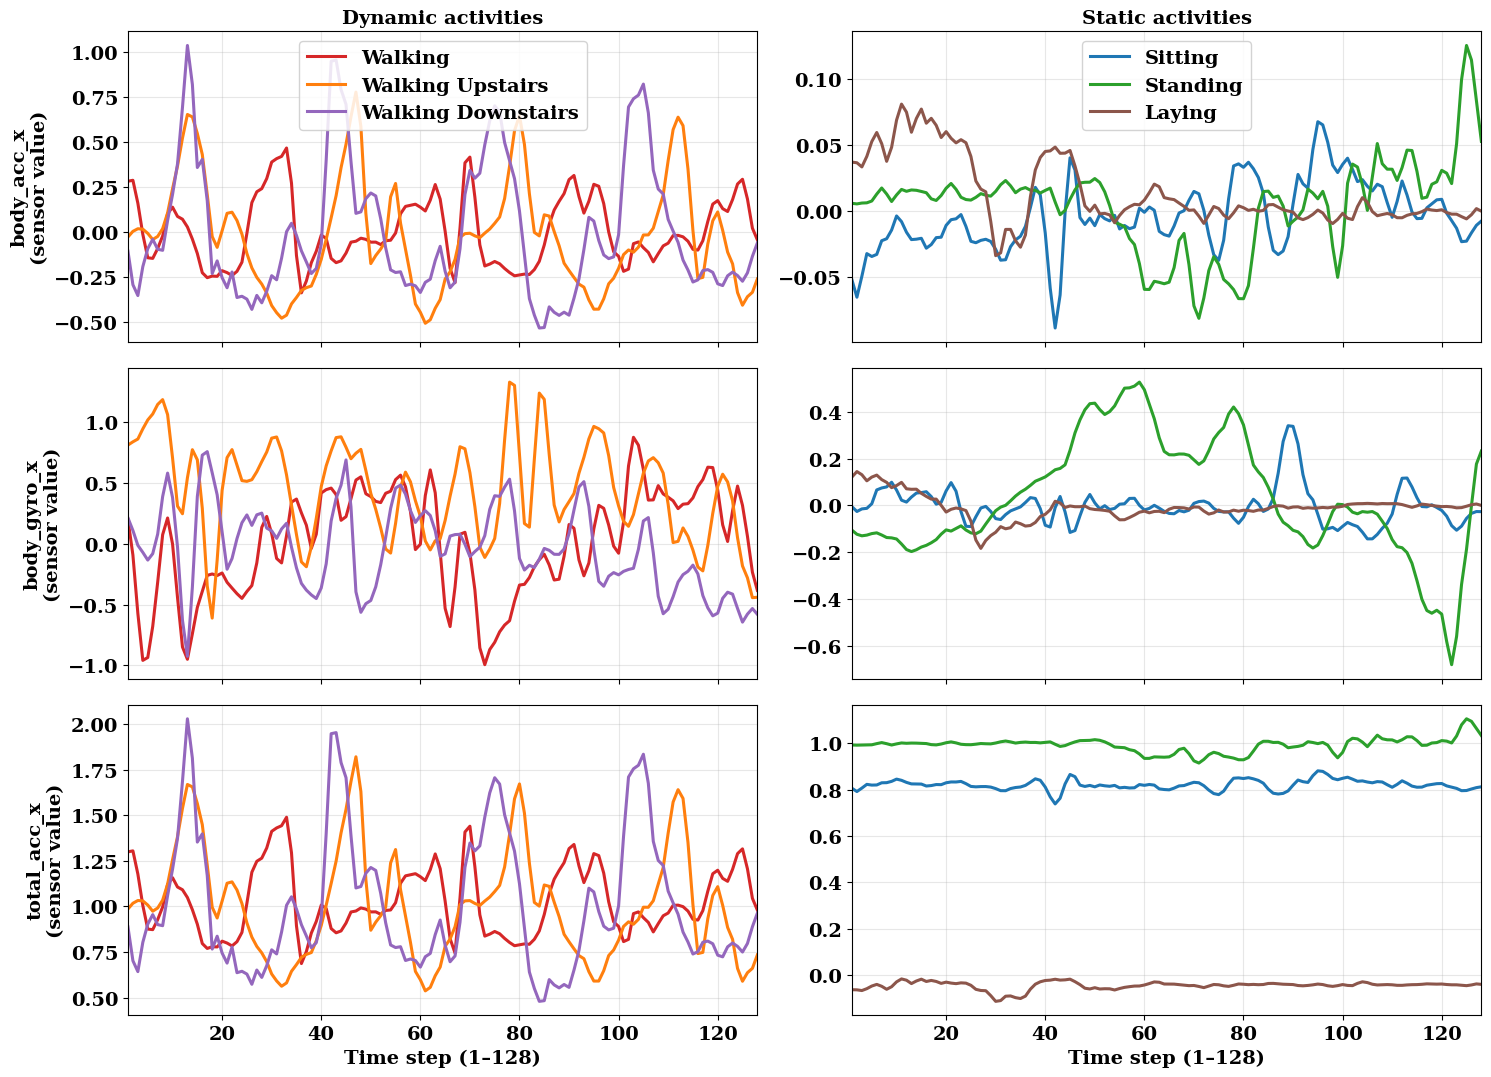

In [7]:
# ===== 6. Plot 1 : sensor signals vs time =====
show_ch = [0, 3, 6]                                                  # body_acc_x, body_gyro_x, total_acc_x
groups = [("Dynamic activities", [0, 1, 2]), ("Static activities", [3, 4, 5])]
rep = {c: int(np.where(y_train == c)[0][0]) for c in range(N_CLASSES)}     # first training window of each class
line_colors = ["tab:red", "tab:orange", "tab:purple", "tab:blue", "tab:green", "tab:brown"]
t = np.arange(1, SEQ_LEN + 1)

fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for r, ch in enumerate(show_ch):
    for cidx, (gname, cls_list) in enumerate(groups):
        ax = axes[r, cidx]
        for c in cls_list:
            ax.plot(t, X_train_raw[rep[c], :, ch], lw=2.2, color=line_colors[c], label=CLASS_LABELS[c])
        ax.grid(alpha=0.3); ax.set_xlim(1, SEQ_LEN)
        if r == 0:
            ax.set_title(gname)
            ax.legend(loc="best", framealpha=0.85)
        if cidx == 0:
            ax.set_ylabel(f"{SIGNALS[ch]}\n(sensor value)")
        if r == 2:
            ax.set_xlabel("Time step (1–128)")
fig.tight_layout(); save_fig(fig, "plot01_sensor_signals"); plt.show()

# data-driven inference: dynamic-vs-static amplitude and the most similar pair of activities
std_ch0 = np.array([X_train_raw[y_train == c][:, :, 0].std(axis=1).mean() for c in range(N_CLASSES)])
feat = np.stack([np.concatenate([X_train_raw[y_train == c].mean(axis=(0, 1)), X_train_raw[y_train == c].std(axis=(0, 1))])
                 for c in range(N_CLASSES)])
feat = (feat - feat.mean(0)) / (feat.std(0) + 1e-9)
dmat = np.linalg.norm(feat[:, None] - feat[None], axis=-1); np.fill_diagonal(dmat, np.inf)
ia, ib = np.unravel_index(dmat.argmin(), dmat.shape)
inference("plot1",
    f"Dynamic activities oscillate (body_acc_x std {std_ch0[:3].mean():.2f} vs {std_ch0[3:].mean():.2f} static); most similar: {CLASS_LABELS[ia]} & {CLASS_LABELS[ib]}.",
    "Order matters: gait cycles and posture changes exist only along time; shuffling the steps destroys them.")

## 8. Backpropagation Through Time (BPTT)
**Numerical exercise** — $x=(0.5,0.7,0.2),\ h_0=0,\ W_x=0.5,\ W_h=0.8,\ b=0.1$ (hand calculation, 4 d.p.):

* $h_1=\tanh(0.5\cdot0.5+0.8\cdot0+0.1)=\tanh(0.35)=\mathbf{0.3364}$
* $h_2=\tanh(0.5\cdot0.7+0.8\cdot0.3364+0.1)=\tanh(0.7191)=\mathbf{0.6164}$
* $h_3=\tanh(0.5\cdot0.2+0.8\cdot0.6164+0.1)=\tanh(0.6931)=\mathbf{0.6000}$

The cell below compares these with a NumPy loop and with an actual Keras `SimpleRNN` carrying the same weights.

In [8]:
# ===== 8. Numerical exercise: manual vs NumPy vs Keras SimpleRNN =====
x_seq, Wx, Wh, b = [0.5, 0.7, 0.2], 0.5, 0.8, 0.1
manual = [0.3364, 0.6164, 0.6000]                                    # hand calculation (see markdown above)

h_prev, h_np = 0.0, []
for xt in x_seq:                                                     # NumPy implementation of h_t = tanh(Wx x_t + Wh h_{t-1} + b)
    h_prev = np.tanh(Wx * xt + Wh * h_prev + b); h_np.append(float(h_prev))

inp = keras.Input(shape=(3, 1)); rnn = layers.SimpleRNN(1, activation="tanh", return_sequences=True)
m_chk = keras.Model(inp, rnn(inp))
rnn.set_weights([np.array([[Wx]], "float32"), np.array([[Wh]], "float32"), np.array([b], "float32")])
h_keras = m_chk.predict(np.array(x_seq, "float32").reshape(1, 3, 1), verbose=0).ravel()

cmp_df = pd.DataFrame({"Manual (4 d.p.)": manual, "NumPy": np.round(h_np, 6), "Keras SimpleRNN": np.round(h_keras, 6)},
                      index=["h1", "h2", "h3"])
cmp_df["|NumPy - Manual|"] = (cmp_df["NumPy"] - cmp_df["Manual (4 d.p.)"]).abs()
display(cmp_df); save_table(cmp_df, "bptt_numerical_exercise")
inference("bptt_numeric",
    f"Manual, NumPy and Keras agree: h = [{', '.join(f'{v:.4f}' for v in h_np)}] (max diff {cmp_df['|NumPy - Manual|'].max():.0e}, from 4-d.p. rounding).",
    "The same Wx, Wh, b are reused at every step; only the hidden state carries the past forward.")

,Manual (4 d.p.),NumPy,Keras SimpleRNN,|NumPy - Manual|
h1,0.3364,0.336376,0.336376,0.000024
h2,0.6164,0.616352,0.616352,0.000048
h3,0.6000,0.599958,0.599958,0.000042


[saved] /content/outputs/tables/bptt_numerical_exercise.csv


## 9. RNN Implementation
Architecture: `Input(128×9) → SimpleRNN(32) → Dropout(0.2) → Dense(16, ReLU) → Dense(6, softmax)`; Adam (lr 1e-3), batch 32, 30 epochs, sparse categorical cross-entropy.
The weights of the epoch with the lowest **validation** loss are restored before testing (model selection never touches the test set). A one-epoch warm-up of each architecture runs first so GPU/cuDNN initialisation does not distort the measured training times.

In [9]:
# ===== 9. RNN implementation: model builder + training/evaluation routine (reused for LSTM / GRU) =====
RNN_LAYER = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}

def build_classifier(kind, T=SEQ_LEN, n_features=N_FEATURES, n_classes=N_CLASSES, units=UNITS,
                     n_layers=1, bidirectional=False, dropout=DROPOUT):
    """Input (T,9) -> recurrent layer(s) -> Dropout -> Dense(16, ReLU) -> Dense(6, softmax). Only the recurrent layer changes."""
    Rec = RNN_LAYER[kind]
    inp = keras.Input(shape=(T, n_features), name="sensor_window")
    x = inp
    for i in range(n_layers):
        layer = Rec(units, return_sequences=(i < n_layers - 1))
        x = (layers.Bidirectional(layer) if bidirectional else layer)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inp, out, name=f"{'Bi' if bidirectional else ''}{kind}_{units}u_{n_layers}L")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def train_eval(kind, data, T=SEQ_LEN, units=UNITS, n_layers=1, bidirectional=False, epochs=EPOCHS, verbose_every=5, tag=None):
    set_seed()
    Xtr, Xva, Xte = data["X_train"][:, :T], data["X_val"][:, :T], data["X_test"][:, :T]      # truncate to the first T steps
    model = build_classifier(kind, T, N_FEATURES, N_CLASSES, units, n_layers, bidirectional)
    rb = RestoreBest()
    t0 = time.perf_counter()
    hist = model.fit(Xtr, data["y_train"], validation_data=(Xva, data["y_val"]), epochs=epochs, batch_size=BATCH,
                     callbacks=[rb, EpochPrinter(verbose_every)], verbose=0)
    train_time = time.perf_counter() - t0
    y_pred = model.predict(Xte, batch_size=256, verbose=0).argmax(axis=1)
    res = dict(kind=kind, tag=tag or kind, model=model, history=hist.history, best_epoch=rb.epoch, params=count_params(model),
               train_time=train_time, y_pred=y_pred, cm=confusion_matrix(data["y_test"], y_pred, labels=range(N_CLASSES)),
               **evaluate_classifier(data["y_test"], y_pred))
    return res

def summarize(r):
    print(f"==> {r['tag']}: test acc {r['accuracy']:.2f}% | macro-F1 {r['f1']:.2f}% | params {r['params']:,} | "
          f"train time {r['train_time']:.1f}s | best epoch {r['best_epoch']}")

# warm-up (results discarded): initialises CUDA / cuDNN kernels so the first timed model is not penalised
for _k in MODELS:
    _m = build_classifier(_k); _m.fit(data["X_train"][:128], data["y_train"][:128], epochs=1, batch_size=BATCH, verbose=0); del _m
keras.backend.clear_session()

RESULTS = {}
print("Training RNN ...")
RESULTS["RNN"] = train_eval("RNN", data)
RESULTS["RNN"]["model"].summary()
summarize(RESULTS["RNN"])

Training RNN ...
   epoch   1 | loss 1.6319  acc  36.4% | val_loss 1.4551  val_acc  45.6%
   epoch   5 | loss 1.0377  acc  53.2% | val_loss 1.2108  val_acc  47.2%
   epoch  10 | loss 0.8852  acc  59.0% | val_loss 0.7798  val_acc  67.1%
   epoch  15 | loss 0.7223  acc  65.8% | val_loss 0.6614  val_acc  71.0%
   epoch  20 | loss 0.6667  acc  69.7% | val_loss 0.6225  val_acc  69.2%
   epoch  25 | loss 0.6332  acc  71.3% | val_loss 0.6163  val_acc  71.5%
   epoch  30 | loss 0.6169  acc  73.0% | val_loss 0.5770  val_acc  72.8%


Model: "RNN_32u_1L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924 (23.14 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,950 (15.43 KB)

==> RNN: test acc 72.16% | macro-F1 73.03% | params 1,974 | train time 30.6s | best epoch 28


## 10. LSTM Architecture
An LSTM adds a **cell state** $C_t$ and three gates (all sigmoid):
$$f_t=\sigma(W_f[h_{t-1},x_t]+b_f),\quad i_t=\sigma(W_i[h_{t-1},x_t]+b_i),\quad o_t=\sigma(W_o[h_{t-1},x_t]+b_o)$$
$$\tilde C_t=\tanh(W_C[h_{t-1},x_t]+b_C),\qquad C_t=f_t\odot C_{t-1}+i_t\odot\tilde C_t,\qquad h_t=o_t\odot\tanh(C_t)$$

In [10]:
# ===== 10. Required inference (conceptual): how cell state and gates retain / discard information =====
inference("lstm_concept",
    "C_t = f_t⊙C_{t−1} + i_t⊙C̃_t is an additive path: f_t≈1 keeps memory, f_t≈0 discards it.",
    "The input gate writes new evidence; the output gate decides how much memory is exposed as h_t.")

## 11. GRU Architecture
A GRU has two gates and a single state:
$$z_t=\sigma(W_z[h_{t-1},x_t]+b_z),\quad r_t=\sigma(W_r[h_{t-1},x_t]+b_r),\quad \tilde h_t=\tanh(W_h[r_t\odot h_{t-1},x_t]+b_h),\quad h_t=(1-z_t)\,h_{t-1}+z_t\,\tilde h_t$$

In [11]:
# ===== 11. Comparison of gates / state representations =====
inference("gru_concept",
    "RNN: 1 state, 0 gates · LSTM: h and C, 3 gates (forget, input, output) · GRU: 1 state, 2 gates (update, reset).",
    "The update gate blends old state and candidate → short gradient path with fewer weights than LSTM.")

## 12. LSTM and GRU Implementation
Identical classifier, only the recurrent layer is replaced (`LSTM(32)` / `GRU(32)`); all other conditions unchanged.

In [12]:
# ===== 12. LSTM and GRU implementation =====
for kind in ("LSTM", "GRU"):
    print(f"\nTraining {kind} ...")
    RESULTS[kind] = train_eval(kind, data)
    RESULTS[kind]["model"].summary()
    summarize(RESULTS[kind])


Training LSTM ...
   epoch   1 | loss 1.5907  acc  34.7% | val_loss 1.3709  val_acc  40.2%
   epoch   5 | loss 0.6550  acc  75.3% | val_loss 0.4717  val_acc  83.2%
   epoch  10 | loss 0.2954  acc  88.9% | val_loss 0.2271  val_acc  93.0%
   epoch  15 | loss 0.2079  acc  91.3% | val_loss 0.2099  val_acc  96.4%
   epoch  20 | loss 0.2873  acc  89.6% | val_loss 0.4409  val_acc  87.0%
   epoch  25 | loss 0.1351  acc  95.0% | val_loss 0.1465  val_acc  96.1%
   epoch  30 | loss 0.1215  acc  95.1% | val_loss 0.1887  val_acc  95.9%


Model: "LSTM_32u_1L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_window (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,020 (70.39 KB)

 Trainable params: 6,006 (23.46 KB)

...

 Total params: 14,276 (55.77 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,518 (37.18 KB)

==> GRU: test acc 98.29% | macro-F1 98.29% | params 4,758 | train time 26.3s | best epoch 25


## 13. Required Training Plots — **Plot 2** (loss) and **Plot 3** (accuracy) for RNN, LSTM, GRU

[saved] /content/outputs/plots/plot02_loss_RNN.png


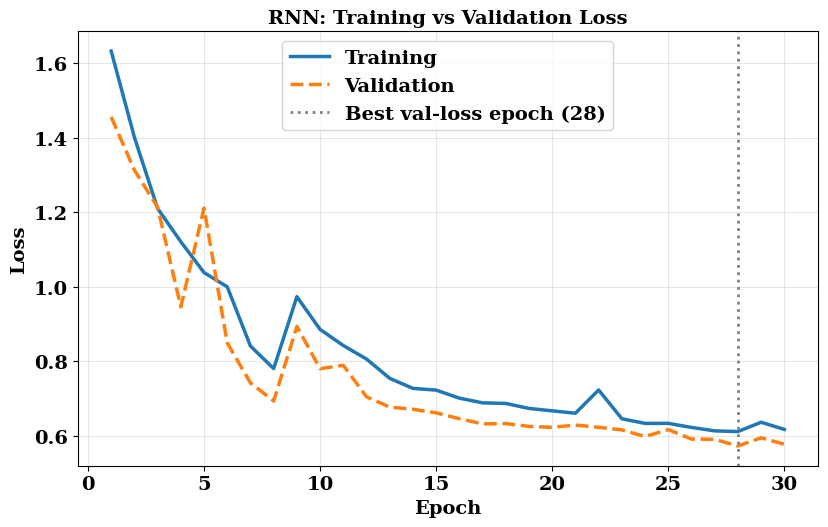

[saved] /content/outputs/plots/plot03_accuracy_RNN.png


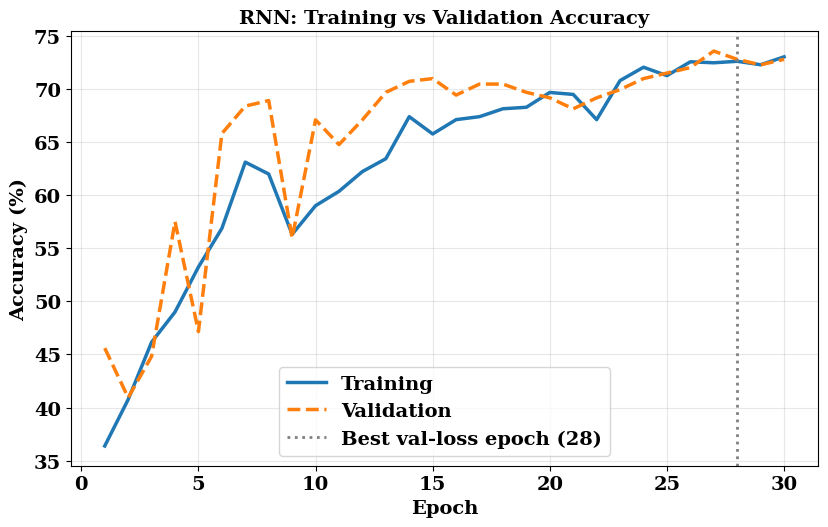

In [13]:
# ===== 13. RNN: Plot 2 (loss) + Plot 3 (accuracy) =====
REASON = {"RNN":  "no gates, so gradients vanish over 128 steps",
          "LSTM": "the gated cell state preserves gradients",
          "GRU":  "the update gate gives a short gradient path"}
r = RESULTS["RNN"]
plot_training_curves(r["history"], r["best_epoch"], "RNN", "loss", "plot02_loss_RNN")
loss_inference("loss_RNN", "RNN", r["history"], REASON["RNN"])
plot_training_curves(r["history"], r["best_epoch"], "RNN", "accuracy", "plot03_accuracy_RNN")
acc_inference("acc_RNN", "RNN", r["history"])

[saved] /content/outputs/plots/plot02_loss_LSTM.png


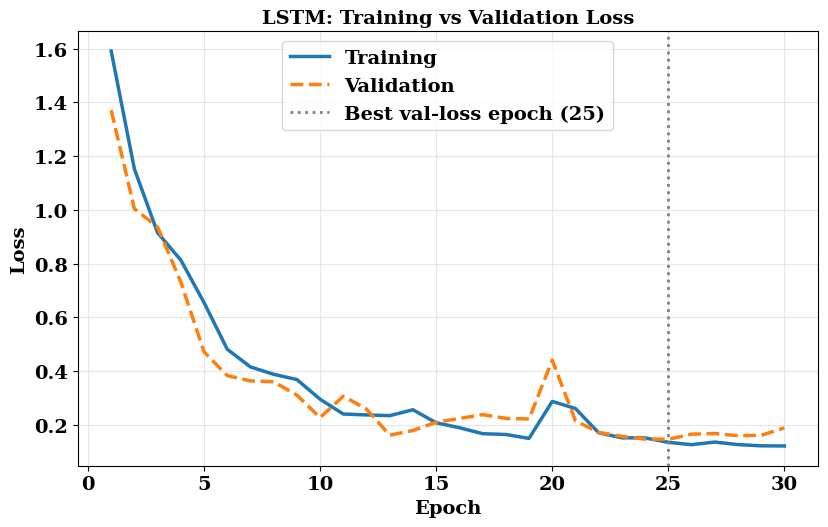

[saved] /content/outputs/plots/plot03_accuracy_LSTM.png


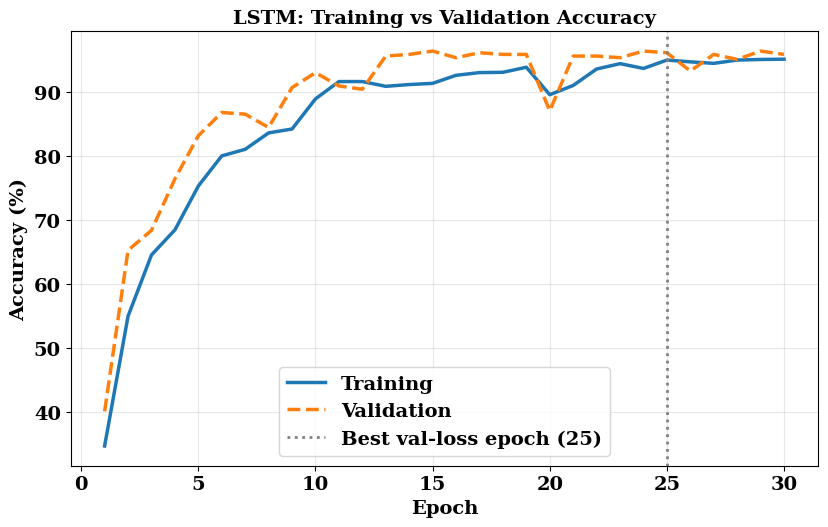

In [14]:
# ===== 13. LSTM: Plot 2 (loss) + Plot 3 (accuracy) =====
r = RESULTS["LSTM"]
plot_training_curves(r["history"], r["best_epoch"], "LSTM", "loss", "plot02_loss_LSTM")
loss_inference("loss_LSTM", "LSTM", r["history"], REASON["LSTM"])
plot_training_curves(r["history"], r["best_epoch"], "LSTM", "accuracy", "plot03_accuracy_LSTM")
acc_inference("acc_LSTM", "LSTM", r["history"])

[saved] /content/outputs/plots/plot02_loss_GRU.png


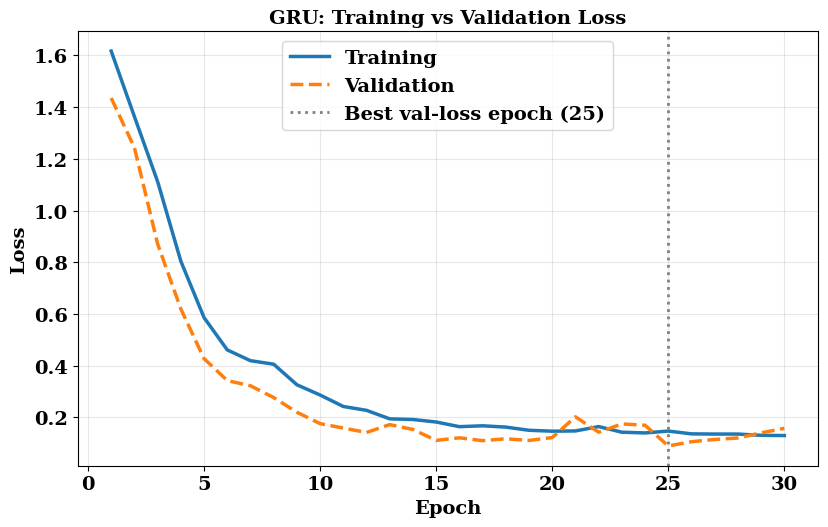

[saved] /content/outputs/plots/plot03_accuracy_GRU.png


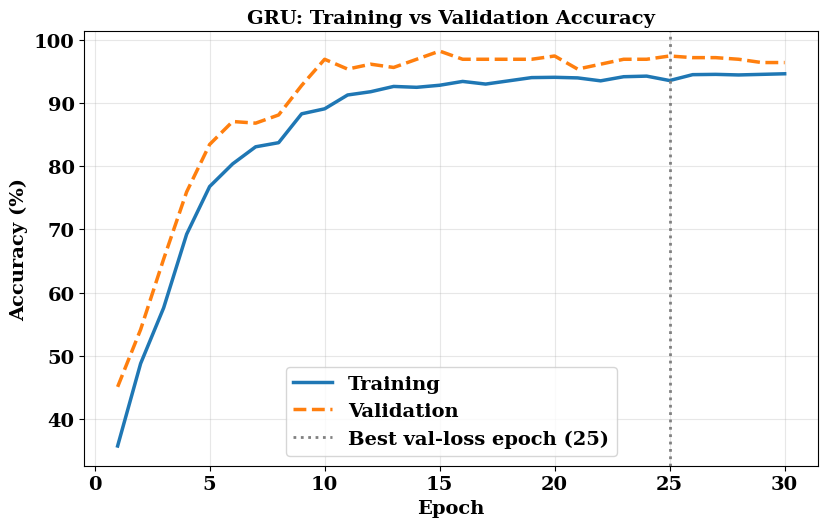

In [15]:
# ===== 13. GRU: Plot 2 (loss) + Plot 3 (accuracy) =====
r = RESULTS["GRU"]
plot_training_curves(r["history"], r["best_epoch"], "GRU", "loss", "plot02_loss_GRU")
loss_inference("loss_GRU", "GRU", r["history"], REASON["GRU"])
plot_training_curves(r["history"], r["best_epoch"], "GRU", "accuracy", "plot03_accuracy_GRU")
acc_inference("acc_GRU", "GRU", r["history"])

## 14. Performance Evaluation (independent test set)
Macro-averaged Precision / Recall / F1; parameters = trainable weights; training time = wall-clock time of `fit` (includes per-epoch validation).

In [16]:
# ===== 14. Performance table =====
rows = ["Accuracy (%)", "Macro Precision (%)", "Macro Recall (%)", "Macro F1 (%)", "Parameters", "Training Time (s)"]
perf = pd.DataFrame({k: [f"{RESULTS[k]['accuracy']:.2f}", f"{RESULTS[k]['precision']:.2f}", f"{RESULTS[k]['recall']:.2f}",
                         f"{RESULTS[k]['f1']:.2f}", f"{RESULTS[k]['params']:,}", f"{RESULTS[k]['train_time']:.1f}"] for k in MODELS},
                    index=pd.Index(rows, name="Metric"))
display(perf); save_table(perf, "table14_performance")

order = sorted(MODELS, key=lambda k: -RESULTS[k]["f1"]); best, worst = order[0], order[-1]
inference("table14",
    "Test macro-F1: " + " > ".join(f"{k} {RESULTS[k]['f1']:.1f}%" for k in order) + ".",
    f"{best} is best (+{RESULTS[best]['f1'] - RESULTS[worst]['f1']:.1f} pts over {worst}); gaps under ~1–2 pts may be noise on {len(y_test)} test windows.")

,RNN,LSTM,GRU
Metric,,,
Accuracy (%),72.16,94.86,98.29
Macro Precision (%),72.80,95.45,98.42
Macro Recall (%),74.42,94.93,98.23
Macro F1 (%),73.03,94.84,98.29
Parameters,"1,974","6,006","4,758"
Training Time (s),30.6,25.5,26.3


[saved] /content/outputs/tables/table14_performance.csv


## 15. Confusion Matrix Analysis — **Plot 4** (one matrix per model)

[saved] /content/outputs/plots/plot04_confusion_RNN.png


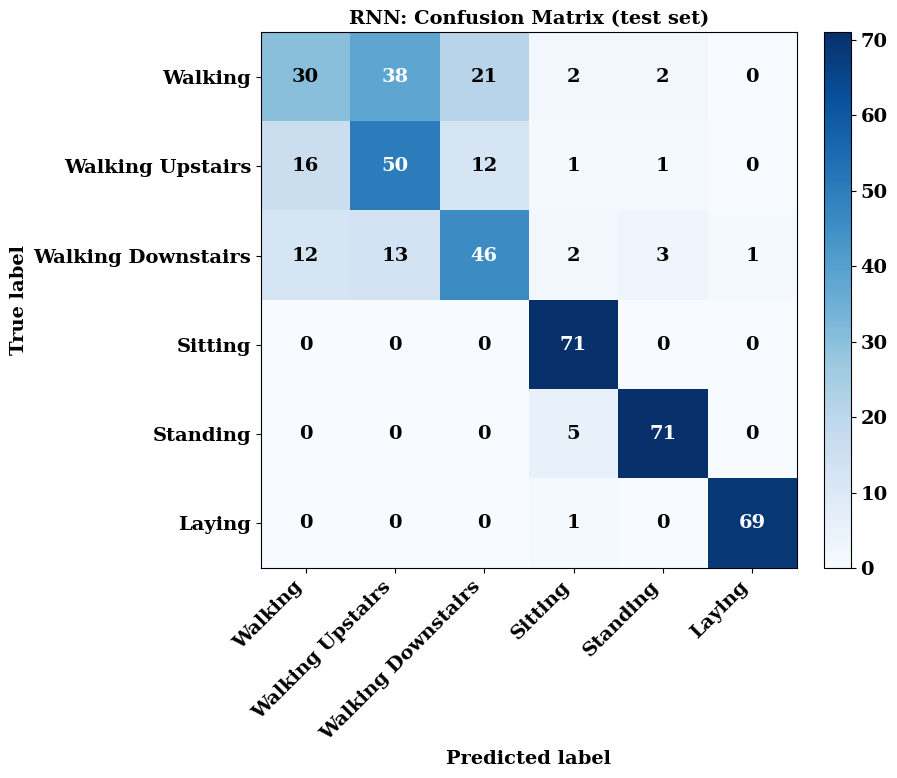

[saved] /content/outputs/plots/plot04_confusion_LSTM.png


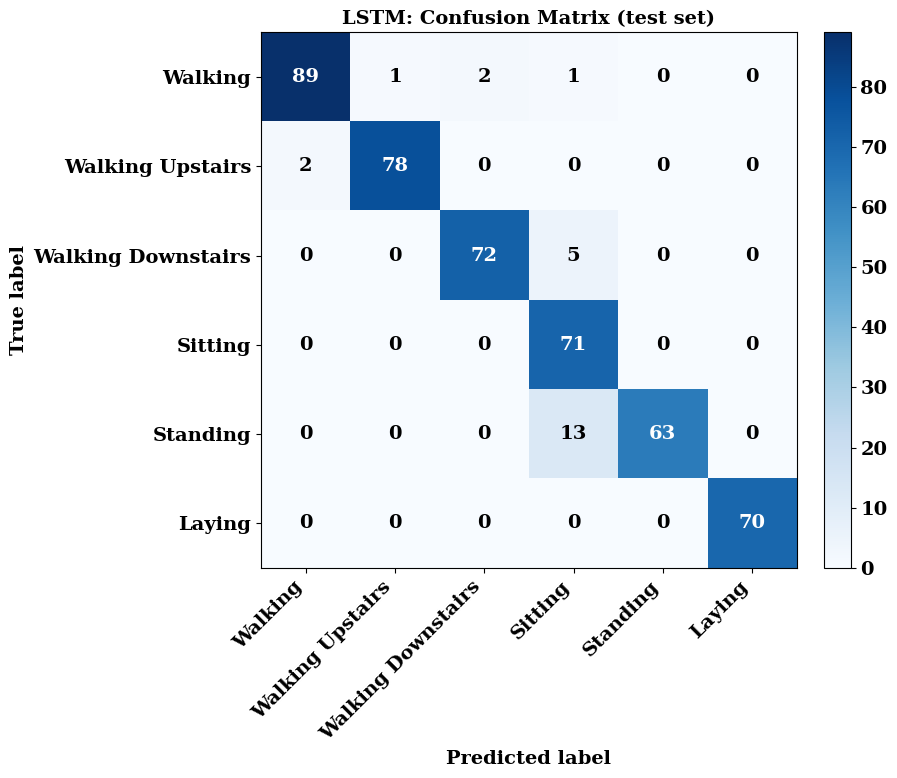

[saved] /content/outputs/plots/plot04_confusion_GRU.png


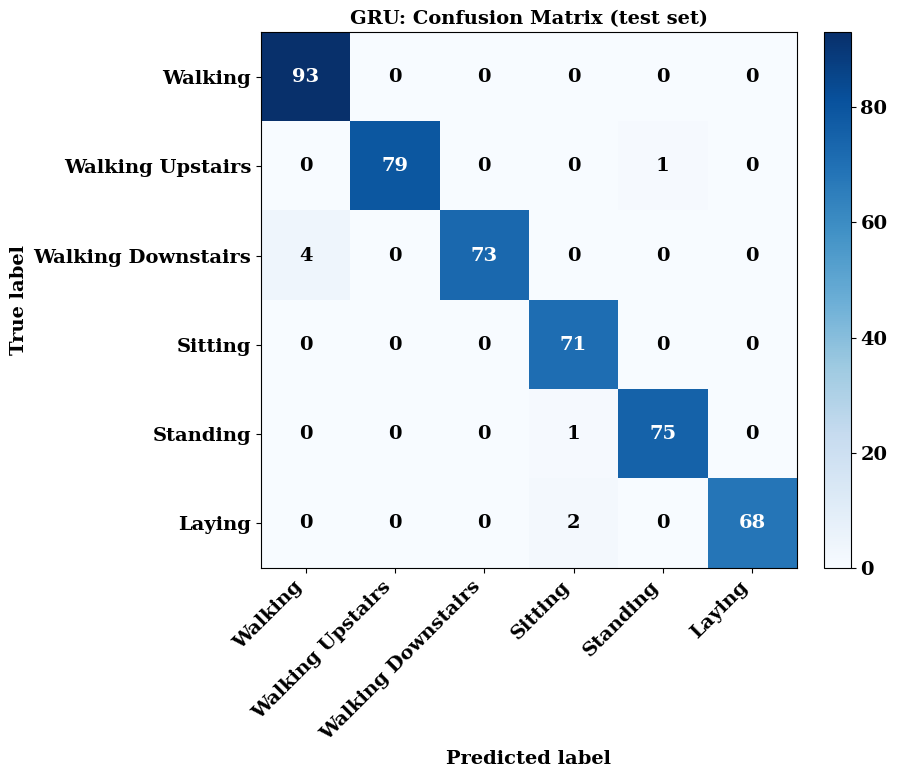

In [17]:
# ===== 15. Plot 4: confusion matrices (separate figure per model) =====
CM_FACTS = {}
for k in MODELS:
    plot_confusion(RESULTS[k]["cm"], CLASS_LABELS, f"{k}: Confusion Matrix (test set)", f"plot04_confusion_{k}")
    CM_FACTS[k] = cm_inference(f"cm_{k}", k, RESULTS[k]["cm"], CLASS_LABELS, why_fn=har_pair_why)

worsts = {k: CM_FACTS[k]["worst"] for k in MODELS}
pairs = {k: frozenset(CM_FACTS[k]["pair"]) for k in MODELS}
same_pair = len(set(pairs.values())) == 1
same_worst = len(set(worsts.values())) == 1
n_same_pair = max(list(pairs.values()).count(v) for v in pairs.values())
verdict = "consistent" if (same_pair and same_worst) else "partly consistent" if (n_same_pair > 1 or len(set(worsts.values())) < 3) else "model-specific"
inference("cm_consistency",
    "Most-errors class: " + ", ".join(f"{k}={worsts[k]}" for k in MODELS) + ".",
    f"Top confusion pair is {'the same' if same_pair else f'shared by {n_same_pair} of 3' if n_same_pair > 1 else 'different'} across models → errors are {verdict}.")

## 16. RNN vs. LSTM vs. GRU Comparison — **Plot 5**

,RNN,LSTM,GRU
Property,,,
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes
Parameters,"1,974","6,006","4,758"
Training time,30.6 s,25.5 s,26.3 s


[saved] /content/outputs/tables/table16_comparison.csv
[saved] /content/outputs/plots/plot05_model_comparison.png


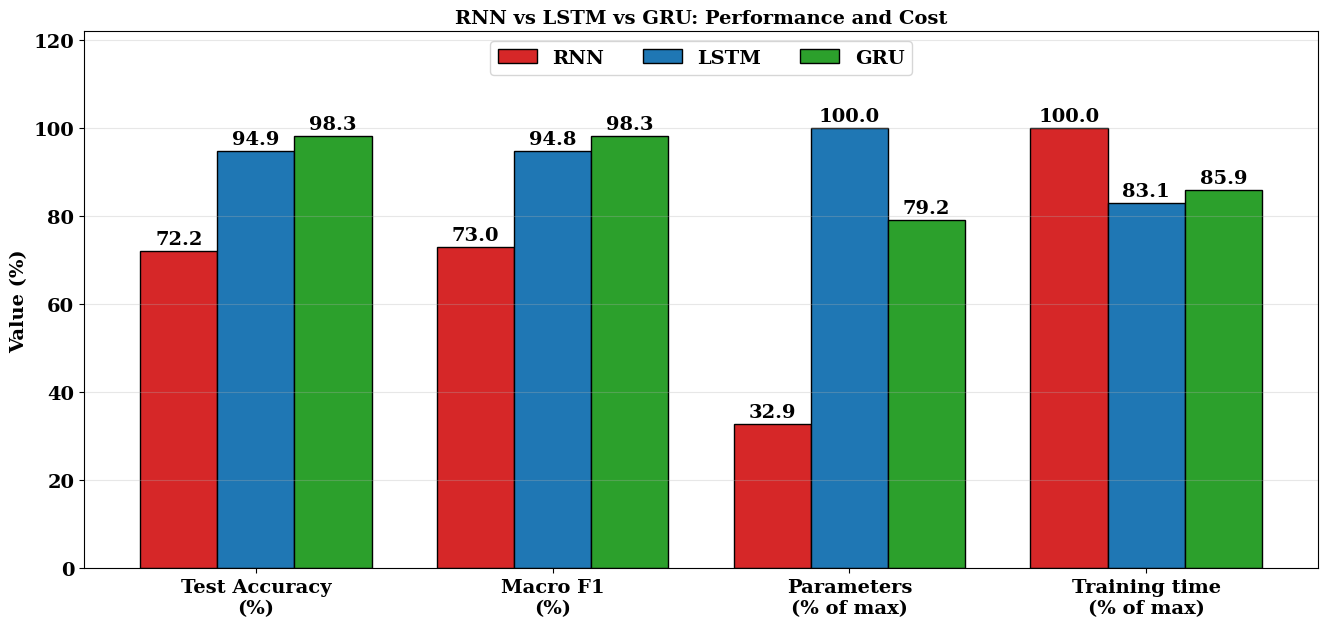

In [18]:
# ===== 16. Comparison table + Plot 5 =====
yn = lambda *v: list(v)
cmp_tbl = pd.DataFrame({
    "RNN":  yn("Yes", "No", "No", "No", "No", "No", "No"),
    "LSTM": yn("Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"),
    "GRU":  yn("Yes", "No", "No", "No", "No", "Yes", "Yes")},
    index=["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate", "Update gate", "Reset gate"])
for lab, fn in (("Parameters", lambda k: f"{RESULTS[k]['params']:,}"), ("Training time", lambda k: f"{RESULTS[k]['train_time']:.1f} s"),
                ("Test F1-score", lambda k: f"{RESULTS[k]['f1']:.2f} %")):
    cmp_tbl.loc[lab] = [fn(k) for k in MODELS]
cmp_tbl.index.name = "Property"
display(cmp_tbl); save_table(cmp_tbl, "table16_comparison")

# Plot 5: accuracy, macro-F1 and normalised computational measures
max_p = max(RESULTS[k]["params"] for k in MODELS); max_t = max(RESULTS[k]["train_time"] for k in MODELS)
metric_names = ["Test Accuracy\n(%)", "Macro F1\n(%)", "Parameters\n(% of max)", "Training time\n(% of max)"]
vals = {k: [RESULTS[k]["accuracy"], RESULTS[k]["f1"], 100 * RESULTS[k]["params"] / max_p, 100 * RESULTS[k]["train_time"] / max_t] for k in MODELS}
x, w = np.arange(len(metric_names)), 0.26
fig, ax = plt.subplots(figsize=(13.5, 6.5))
for i, k in enumerate(MODELS):
    bars = ax.bar(x + (i - 1) * w, vals[k], w, color=COLORS[k], label=k, edgecolor="black")
    ax.bar_label(bars, fmt="%.1f", padding=2)
ax.set_xticks(x); ax.set_xticklabels(metric_names); ax.set_ylim(0, 122)
ax.set_ylabel("Value (%)"); ax.set_title("RNN vs LSTM vs GRU: Performance and Cost")
ax.grid(axis="y", alpha=0.3); ax.legend(loc="upper center", ncol=3)
fig.tight_layout(); save_fig(fig, "plot05_model_comparison"); plt.show()

P, Tm = {k: RESULTS[k]["params"] for k in MODELS}, {k: RESULTS[k]["train_time"] for k in MODELS}
dF = RESULTS["GRU"]["f1"] - RESULTS["LSTM"]["f1"]
dt = 100 * (1 - Tm["GRU"] / Tm["LSTM"])
inference("plot5",
    "F1: " + ", ".join(f"{k} {RESULTS[k]['f1']:.1f}" for k in MODELS) + f" | params 1:{P['LSTM']/P['RNN']:.1f}:{P['GRU']/P['RNN']:.1f} | time 1:{Tm['LSTM']/Tm['RNN']:.1f}:{Tm['GRU']/Tm['RNN']:.1f} (RNN:LSTM:GRU).",
    f"Trade-off: {max(MODELS, key=lambda k: RESULTS[k]['f1'])} has best F1; GRU vs LSTM {dF:+.1f} F1 pts, {100*(1-P['GRU']/P['LSTM']):.0f}% fewer params, {abs(dt):.0f}% {'less' if dt >= 0 else 'more'} time.")

## 17. Effect of Sequence Length — **Plot 6**
Same experiment for $T\in\{32,64,128\}$. Shorter inputs are obtained by **truncating each normalised window to its first T steps** (the same rule for all models; HAR is sampled at 50 Hz, so 32/64/128 steps ≈ 0.64/1.28/2.56 s). The $T=128$ results are reused from Section 14.


--- RNN, T = 32 ---
   epoch   1 | loss 1.6043  acc  38.3% | val_loss 1.2774  val_acc  50.8%
   epoch  10 | loss 0.6768  acc  68.0% | val_loss 0.6197  val_acc  75.1%
   epoch  20 | loss 0.5777  acc  75.2% | val_loss 0.4972  val_acc  80.3%
   epoch  30 | loss 0.5765  acc  76.2% | val_loss 0.6021  val_acc  75.1%
==> RNN-T32: test acc 80.94% | macro-F1 81.97% | params 1,974 | train time 20.5s | best epoch 25

--- LSTM, T = 32 ---
   epoch   1 | loss 1.5997  acc  35.4% | val_loss 1.3931  val_acc  40.9%
   epoch  10 | loss 0.3707  acc  84.4% | val_loss 0.3372  val_acc  86.3%
   epoch  20 | loss 0.1834  acc  92.8% | val_loss 0.2064  val_acc  94.0%
   epoch  30 | loss 0.1295  acc  94.9% | val_loss 0.1794  val_acc  94.3%
==> LSTM-T32: test acc 87.58% | macro-F1 87.91% | params 6,006 | train time 21.6s | best epoch 18

--- GRU, T = 32 ---
   epoch   1 | loss 1.6209  acc  34.7% | val_loss 1.4158  val_acc  46.9%
   epoch  10 | loss 0.3608  acc  84.2% | val_loss 0.3224  val_acc  85.8%
   epoch  2

,RNN F1 (%),LSTM F1 (%),GRU F1 (%)
Sequence Length,,,
32,81.97,87.91,94.08
64,82.01,93.22,97.55
128,73.03,94.84,98.29


[saved] /content/outputs/tables/table17_sequence_length.csv
[saved] /content/outputs/plots/plot06_sequence_length_vs_f1.png


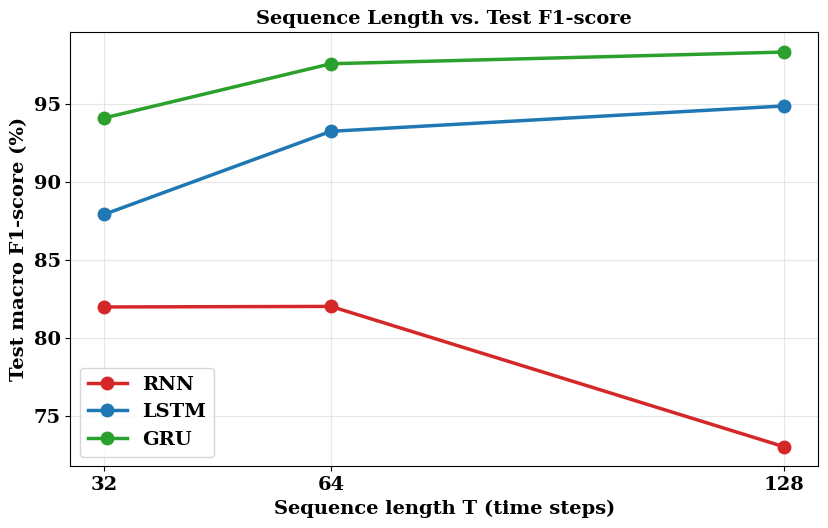

In [19]:
# ===== 17. Sequence-length study =====
SEQ_RESULTS = {SEQ_LEN: RESULTS}
for T in SEQ_LENGTHS:
    if T == SEQ_LEN:
        continue
    SEQ_RESULTS[T] = {}
    for kind in MODELS:
        print(f"\n--- {kind}, T = {T} ---")
        SEQ_RESULTS[T][kind] = train_eval(kind, data, T=T, tag=f"{kind}-T{T}", verbose_every=10)
        summarize(SEQ_RESULTS[T][kind])

seq_tbl = pd.DataFrame({f"{k} F1 (%)": [SEQ_RESULTS[T][k]["f1"] for T in SEQ_LENGTHS] for k in MODELS},
                       index=pd.Index(SEQ_LENGTHS, name="Sequence Length")).round(2)
display(seq_tbl); save_table(seq_tbl, "table17_sequence_length")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for k in MODELS:
    ax.plot(SEQ_LENGTHS, [SEQ_RESULTS[T][k]["f1"] for T in SEQ_LENGTHS], marker="o", ms=9, lw=2.5, color=COLORS[k], label=k)
ax.set_xticks(SEQ_LENGTHS); ax.set_xlabel("Sequence length T (time steps)"); ax.set_ylabel("Test macro F1-score (%)")
ax.set_title("Sequence Length vs. Test F1-score"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); save_fig(fig, "plot06_sequence_length_vs_f1"); plt.show()

T0, T1 = SEQ_LENGTHS[0], SEQ_LENGTHS[-1]
gain = {k: SEQ_RESULTS[T1][k]["f1"] - SEQ_RESULTS[T0][k]["f1"] for k in MODELS}
mean_gain = float(np.mean(list(gain.values())))
if mean_gain > 2:    trend = "More context helps: longer windows cover a full gait/posture cycle"
elif mean_gain < -2: trend = "Longer windows hurt: extra BPTT depth without new information"
else:                trend = "F1 nearly flat: short windows already carry the class information"
bg = max(gain, key=lambda k: abs(gain[k]))
inference("plot6",
    f"Test F1, T={T0}→{T1}: " + ", ".join(f"{k} {SEQ_RESULTS[T0][k]['f1']:.1f}→{SEQ_RESULTS[T1][k]['f1']:.1f}" for k in MODELS) + ".",
    f"{trend} (largest change: {bg}, {gain[bg]:+.1f} pts).")

## 18. Video Understanding Using CNN and RNN
A video is a sequence of frames. A **pretrained CNN** extracts a spatial feature vector from every frame; an **LSTM/GRU** models how those features evolve over time:
```
Video → Frame extraction → Pretrained CNN (MobileNetV2) → Frame features → LSTM/GRU → Dense → Action
```
Dataset: a small subset of **UCF101** (<https://www.crcv.ucf.edu/data/UCF101.php>), 5 action classes (Basketball, Biking, Walking/WalkingWithDog, Running-type action, TennisSwing).

In [20]:
# ===== 18. Get a small UCF101 subset and read videos with OpenCV =====
try:
    import cv2
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"]); import cv2

WANTED = ["Basketball", "Biking", "Walking", "Running", "TennisSwing"]     # names suggested in the manual
ALIASES = {"Walking": ["Walking", "WalkingWithDog"]}
VIDEO_DIR = DATA_DIR / "ucf_subset"; VIDEO_DIR.mkdir(exist_ok=True, parents=True)

def _has_videos(d):
    return any(d.glob("*/*.avi")) or any(d.glob("*/*.mp4"))

def get_ucf_hf():
    """Small UCF101 subset (~170 MB tar.gz, 10 classes, files named v_<Class>_gXX_cXX.avi) from the Hugging Face hub."""
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"], check=False)
    from huggingface_hub import hf_hub_download
    arc = hf_hub_download(repo_id="sayakpaul/ucf101-subset", filename="UCF101_subset.tar.gz", repo_type="dataset",
                          local_dir=str(VIDEO_DIR))
    with tarfile.open(arc) as t:
        t.extractall(VIDEO_DIR)
    print("Extracted UCF101 subset to", VIDEO_DIR)

def get_ucf_official():
    rar = DATA_DIR / "UCF101.rar"
    if not rar.exists():
        print("Downloading UCF101.rar (~6.5 GB) - this takes a while ...")
        download("https://www.crcv.ucf.edu/data/UCF101/UCF101.rar", rar, verify=False)
    subprocess.run("apt-get -qq install -y unrar > /dev/null 2>&1 || pip install -q unrar", shell=True)
    subprocess.run(["unrar", "x", "-o+", "-inul", str(rar), str(VIDEO_DIR / "official") + "/"], check=True)

def collect_videos():
    """Map class name -> list of video paths for the classes we want."""
    all_vids = [p for p in VIDEO_DIR.rglob("*") if p.suffix.lower() in (".avi", ".mp4")]
    by_cls = {}
    for p in all_vids:
        cls = re.sub(r"^v_", "", p.stem).split("_g")[0] if p.stem.startswith("v_") else p.parent.name
        by_cls.setdefault(cls, []).append(str(p))
    return by_cls

kaggle_ucf = glob.glob("/kaggle/input/**/UCF*", recursive=True) if ON_KAGGLE else []
if not any(True for _ in VIDEO_DIR.rglob("*.avi")) and not any(True for _ in VIDEO_DIR.rglob("*.mp4")):
    if kaggle_ucf:                                                            # a UCF101 dataset attached to the notebook
        VIDEO_DIR = Path(kaggle_ucf[0])
    elif VIDEO_SOURCE == "official":
        get_ucf_official()
    else:
        try:
            get_ucf_hf()
        except Exception as e:
            print("Hugging Face route failed:", e, "\nFalling back to the official UCF101.rar ...")
            get_ucf_official()

by_cls = collect_videos()
chosen = []
for w in WANTED:                                                              # pick the wanted classes (with aliases)
    for name in ALIASES.get(w, [w]):
        if name in by_cls and len(by_cls[name]) >= 8 and name not in chosen:
            chosen.append(name); break
for name in sorted(by_cls, key=lambda c: -len(by_cls[c])):                    # top up with the largest remaining classes
    if len(chosen) >= N_VIDEO_CLASSES: break
    if name not in chosen and len(by_cls[name]) >= 8: chosen.append(name)
chosen = chosen[:N_VIDEO_CLASSES]
assert len(chosen) >= 3, f"Need at least 3 action classes with >=8 videos, found {len(chosen)}: {list(by_cls)[:10]}"
V_CLASSES = chosen
print("Selected action classes:", V_CLASSES)
print({c: len(by_cls[c]) for c in V_CLASSES})

UCF101_subset.tar.gz: reconstructing file:   0%|          |  0.00B /  171MB            

UCF101_subset.tar.gz: downloading bytes:           |  0.00B            

Extracted UCF101 subset to /content/data/ucf_subset
Selected action classes: ['Basketball', 'BaseballPitch', 'BabyCrawling', 'BenchPress', 'BandMarching']
{'Basketball': 44, 'BaseballPitch': 43, 'BabyCrawling': 42, 'BenchPress': 42, 'BandMarching': 42}


## 20. CNN Feature Extraction
`MobileNetV2(weights="imagenet", include_top=False, pooling="avg")` is **frozen** and used only as a feature extractor (no CNN training). Features are extracted once and cached, and the recurrent classifier is trained on them.
```
Frame 224×224×3 → MobileNetV2 (frozen) → Global Average Pooling → Feature vector (D) → sequence of 10 features
```

In [21]:
# ===== 19/20. Frame sampling + frozen MobileNetV2 feature extraction =====
def sample_frames(path, n=N_FRAMES, size=IMG_SIZE):
    """Uniformly sample n frames -> (n, size, size, 3) uint8 RGB, or None if the video cannot be read."""
    cap = cv2.VideoCapture(path); total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        frames = []
        while True:
            ok, f = cap.read()
            if not ok: break
            frames.append(f)
        cap.release()
        if len(frames) < 1: return None
        sel = [frames[i] for i in np.linspace(0, len(frames) - 1, n).round().astype(int)]
    else:
        sel = []
        for i in np.linspace(0, total - 1, n).round().astype(int):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i)); ok, f = cap.read()
            if not ok:
                f = sel[-1] if sel else None
                if f is None: cap.release(); return None
            sel.append(f)
        cap.release()
    return np.stack([cv2.resize(cv2.cvtColor(f, cv2.COLOR_BGR2RGB), (size, size)) for f in sel]).astype(np.uint8)

rng = np.random.RandomState(SEED)
video_paths, video_labels = [], []
for ci, c in enumerate(V_CLASSES):
    paths = sorted(by_cls[c]); rng.shuffle(paths)
    paths = paths[:MAX_VIDEOS_PER_CLASS]
    video_paths += paths; video_labels += [ci] * len(paths)
video_labels = np.array(video_labels)
print(f"Videos: {len(video_paths)}  ({', '.join(f'{c}: {int((video_labels==i).sum())}' for i, c in enumerate(V_CLASSES))})")

cnn = keras.applications.MobileNetV2(weights="imagenet", include_top=False, pooling="avg",
                                     input_shape=(IMG_SIZE, IMG_SIZE, 3))
cnn.trainable = False                                                     # frozen: pure feature extractor
FEAT_DIM = cnn.output_shape[-1]

frames_all, feats_all, keep = [], [], []
for i, p in enumerate(tqdm(video_paths, desc="Extracting CNN features")):
    fr = sample_frames(p)
    if fr is None:
        print("skipped unreadable video:", p); continue
    x = keras.applications.mobilenet_v2.preprocess_input(fr.astype("float32"))          # scale to [-1, 1]
    feats_all.append(cnn.predict(x, batch_size=N_FRAMES, verbose=0))                    # (10, D)
    frames_all.append(fr); keep.append(i)
keep = np.array(keep)
V_X = np.stack(feats_all).astype(np.float32)                                            # (B, 10, D)
V_y = video_labels[keep]; V_paths = [video_paths[i] for i in keep]; V_frames = np.stack(frames_all)
print(f"\nFrame tensor per video       : {V_frames.shape[1:]}  (10 frames of 224x224x3)")
print(f"CNN feature dimension D      : {FEAT_DIM}")
print(f"Feature tensor for the LSTM/GRU: {V_X.shape}   i.e. (B, 10, D)")

Videos: 200  (Basketball: 40, BaseballPitch: 40, BabyCrawling: 40, BenchPress: 40, BandMarching: 40)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extracting CNN features:   0%|          | 0/200 [00:00<?, ?it/s]


Frame tensor per video       : (10, 224, 224, 3)  (10 frames of 224x224x3)
CNN feature dimension D      : 1280
Feature tensor for the LSTM/GRU: (200, 10, 1280)   i.e. (B, 10, D)


## 21. CNN–LSTM / CNN–GRU Model
`10 frames → CNN features (10×D) → LSTM/GRU(32) → Dropout → Dense → Softmax`. Both LSTM and GRU are trained on the identical cached features; the better one (by **validation** F1) is used for the video plots. Videos are split 70/15/15 **by source group** where possible (UCF101 clips from the same group `g##` come from one long video, so a random clip split would leak).

In [22]:
# ===== 21. Video split (group-aware), models, training =====
def group_of(path):
    m = re.search(r"_g(\d+)_", os.path.basename(path)); return int(m.group(1)) if m else None

groups = np.array([group_of(p) if group_of(p) is not None else -1 for p in V_paths])
def video_split(y, groups, seed=SEED):
    idx = np.arange(len(y))
    if (groups >= 0).all():                                                # split whole groups (all classes share group ids)
        for t in range(300):
            g = np.random.RandomState(seed + t).permutation(np.unique(groups)); n = len(g)
            te_g, va_g = g[:max(1, round(0.15 * n))], g[max(1, round(0.15 * n)):max(1, round(0.15 * n)) + max(1, round(0.15 * n))]
            m = [np.isin(groups, gg) for gg in (np.setdiff1d(g, np.concatenate([te_g, va_g])), va_g, te_g)]
            if all(len(np.unique(y[mm])) == len(np.unique(y)) for mm in m):
                return [idx[mm] for mm in m]
    tr, te = train_test_split(idx, test_size=0.15, stratify=y, random_state=seed)
    tr, va = train_test_split(tr, test_size=0.15 / 0.85, stratify=y[tr], random_state=seed)
    return tr, va, te

vtr, vva, vte = video_split(V_y, groups)
f_mu, f_sd = V_X[vtr].mean(axis=(0, 1), keepdims=True), V_X[vtr].std(axis=(0, 1), keepdims=True) + 1e-6   # train stats only
VXn = ((V_X - f_mu) / f_sd).astype(np.float32)
print(f"Video split (train/val/test): {len(vtr)}/{len(vva)}/{len(vte)} videos | features {VXn.shape}")

def build_video_model(kind, D=FEAT_DIM, n_classes=len(V_CLASSES)):
    Rec = layers.LSTM if kind == "LSTM" else layers.GRU
    inp = keras.Input(shape=(N_FRAMES, D), name="frame_features")
    x = Rec(VID_UNITS)(inp); x = layers.Dropout(VID_DROPOUT)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    m = keras.Model(inp, out, name=f"CNN_{kind}")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

VIDEO_RES = {}
for kind in ("LSTM", "GRU"):
    set_seed(); m = build_video_model(kind); rb = RestoreBest(); t0 = time.perf_counter()
    h = m.fit(VXn[vtr], V_y[vtr], validation_data=(VXn[vva], V_y[vva]), epochs=VID_EPOCHS, batch_size=VID_BATCH,
              callbacks=[rb, EpochPrinter(10)], verbose=0).history
    tt = time.perf_counter() - t0
    proba = m.predict(VXn, verbose=0); yp = proba[vte].argmax(1)
    yva_pred = proba[vva].argmax(1)
    VIDEO_RES[kind] = dict(kind=kind, model=m, history=h, best_epoch=rb.epoch, params=count_params(m), train_time=tt, proba=proba,
                           y_pred=yp, cm=confusion_matrix(V_y[vte], yp, labels=range(len(V_CLASSES))),
                           val_f1=evaluate_classifier(V_y[vva], yva_pred)["f1"], **evaluate_classifier(V_y[vte], yp))
    print(f"==> CNN-{kind}: test acc {VIDEO_RES[kind]['accuracy']:.1f}% | F1 {VIDEO_RES[kind]['f1']:.1f}% | "
          f"params {VIDEO_RES[kind]['params']:,} | val F1 {VIDEO_RES[kind]['val_f1']:.1f}%")

VBEST = max(VIDEO_RES, key=lambda k: (VIDEO_RES[k]["val_f1"], -VIDEO_RES[k]["params"]))   # selection by VALIDATION only
print("Selected recurrent model for the video plots (best validation F1):", VBEST)
VR = VIDEO_RES[VBEST]

Video split (train/val/test): 139/28/33 videos | features (200, 10, 1280)
   epoch   1 | loss 1.3697  acc  46.8% | val_loss 1.2076  val_acc  64.3%
   epoch  10 | loss 0.0790  acc 100.0% | val_loss 0.1334  val_acc 100.0%
   epoch  20 | loss 0.0166  acc 100.0% | val_loss 0.0552  val_acc 100.0%
   epoch  30 | loss 0.0086  acc 100.0% | val_loss 0.0367  val_acc 100.0%
   epoch  40 | loss 0.0061  acc 100.0% | val_loss 0.0276  val_acc 100.0%
==> CNN-LSTM: test acc 93.9% | F1 93.8% | params 169,285 | val F1 100.0%
   epoch   1 | loss 1.4449  acc  40.3% | val_loss 0.9989  val_acc  71.4%
   epoch  10 | loss 0.0538  acc 100.0% | val_loss 0.1135  val_acc 100.0%
   epoch  20 | loss 0.0122  acc 100.0% | val_loss 0.0439  val_acc 100.0%
   epoch  30 | loss 0.0062  acc 100.0% | val_loss 0.0255  val_acc 100.0%
   epoch  40 | loss 0.0047  acc 100.0% | val_loss 0.0193  val_acc 100.0%
==> CNN-GRU: test acc 93.9% | F1 93.8% | params 127,365 | val F1 100.0%
Selected recurrent model for the video plots (best 

### Predicted vs. actual class with confidence (read from the trained model's softmax)

In [23]:
# ===== 19. Predicted class / actual class / confidence for held-out test videos =====
print(f"Model: CNN-{VBEST}\n")
for j in list(vte[:8]):
    p = VR["proba"][j]; pc = int(p.argmax())
    print(f"Video: {os.path.basename(V_paths[j])}\n   Predicted class : {V_CLASSES[pc]}\n   Actual class    : {V_CLASSES[V_y[j]]}"
          f"\n   Confidence      : {p[pc]:.2f}\n")

Model: CNN-GRU

Video: v_Basketball_g01_c03.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 0.99

Video: v_Basketball_g01_c05.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 0.99

Video: v_Basketball_g24_c02.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 0.99

Video: v_Basketball_g01_c01.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 0.99

Video: v_Basketball_g09_c02.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 0.96

Video: v_Basketball_g17_c04.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 1.00

Video: v_Basketball_g24_c04.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 1.00

Video: v_Basketball_g09_c04.avi
   Predicted class : Basketball
   Actual class    : Basketball
   Confidence      : 0.99



## Plot 7 — Video sample frames (10 uniformly sampled frames of one test video)

[saved] /content/outputs/plots/plot07_video_sample_frames.png


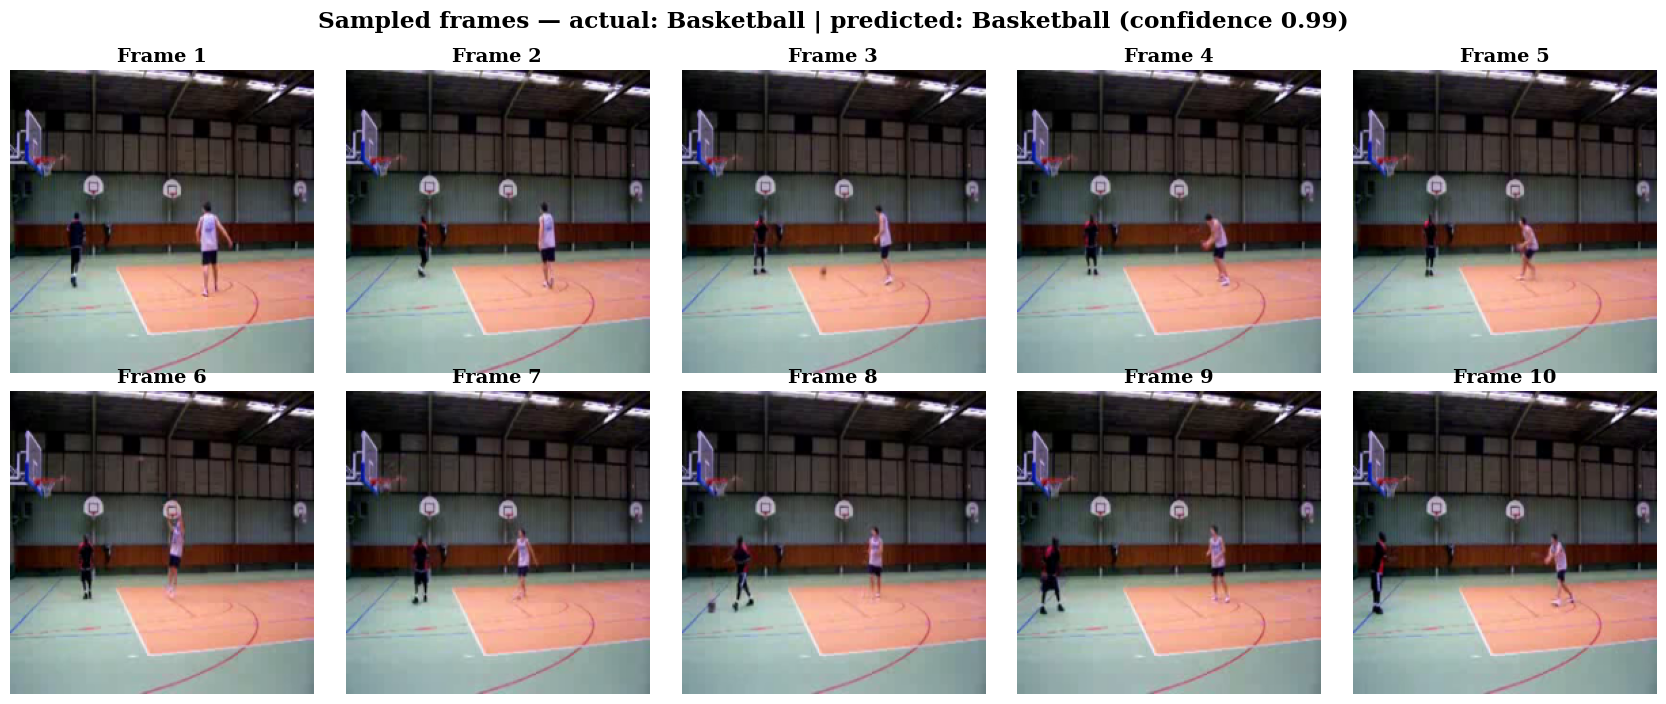

In [24]:
# ===== Plot 7: sampled frames of one video =====
j = int(vte[0]); pc = int(VR["proba"][j].argmax())
fig, axes = plt.subplots(2, 5, figsize=(17, 7.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(V_frames[j][i]); ax.axis("off"); ax.set_title(f"Frame {i+1}")
fig.suptitle(f"Sampled frames — actual: {V_CLASSES[V_y[j]]} | predicted: {V_CLASSES[pc]} (confidence {VR['proba'][j][pc]:.2f})")
fig.tight_layout(); save_fig(fig, "plot07_video_sample_frames"); plt.show()
inference("plot7",
    f"10 frames (224×224) of a '{V_CLASSES[V_y[j]]}' video → the CNN gives one {FEAT_DIM}-d vector per frame: objects, scene, pose (spatial).",
    "The LSTM/GRU reads the 10 vectors in order and learns how they change (motion, repetition) — the temporal cue.")

## Plot 8 — Video training / validation curves

[saved] /content/outputs/plots/plot08_video_training_curves.png


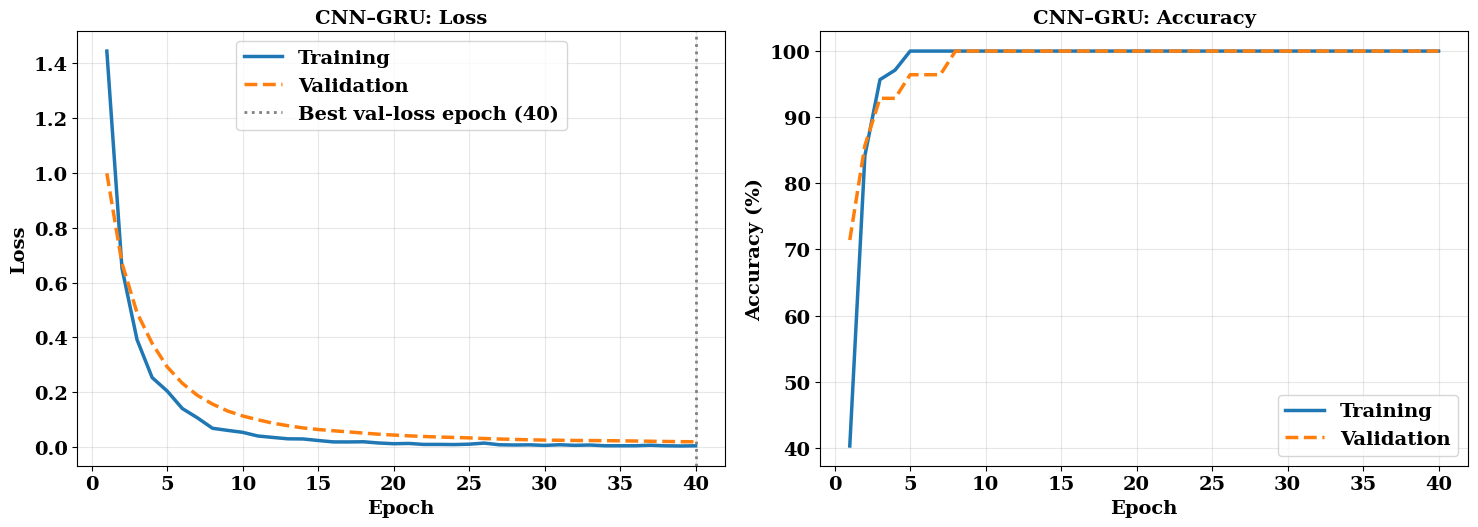

In [25]:
# ===== Plot 8: video training curves (loss + accuracy for the selected architecture) =====
h = VR["history"]; ep = np.arange(1, len(h["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(ep, h["loss"], color="tab:blue", lw=2.5, label="Training"); axes[0].plot(ep, h["val_loss"], color="tab:orange", lw=2.5, ls="--", label="Validation")
axes[0].axvline(VR["best_epoch"], color="gray", ls=":", lw=2, label=f"Best val-loss epoch ({VR['best_epoch']})")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title(f"CNN–{VBEST}: Loss"); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(ep, np.array(h["accuracy"]) * 100, color="tab:blue", lw=2.5, label="Training"); axes[1].plot(ep, np.array(h["val_accuracy"]) * 100, color="tab:orange", lw=2.5, ls="--", label="Validation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title(f"CNN–{VBEST}: Accuracy"); axes[1].grid(alpha=0.3); axes[1].legend()
fig.tight_layout(); save_fig(fig, "plot08_video_training_curves"); plt.show()
fv = curve_facts(h)
inference("plot8",
    f"CNN–{VBEST}: train loss {fv['tl0']:.2f}→{fv['tl_end']:.2f}, val loss min {fv['vl_min']:.2f} (epoch {fv['best_ep']}/{fv['E']}); final train/val acc {fv['ta_end']:.0f}/{fv['va_end']:.0f}%.",
    f"{STATUS_TXT[diagnose(fv)]} — only {len(vtr)} training / {len(vva)} validation videos, so the curves are noisy.")

## Plot 9 — Video confusion matrix

[saved] /content/outputs/plots/plot09_video_confusion.png


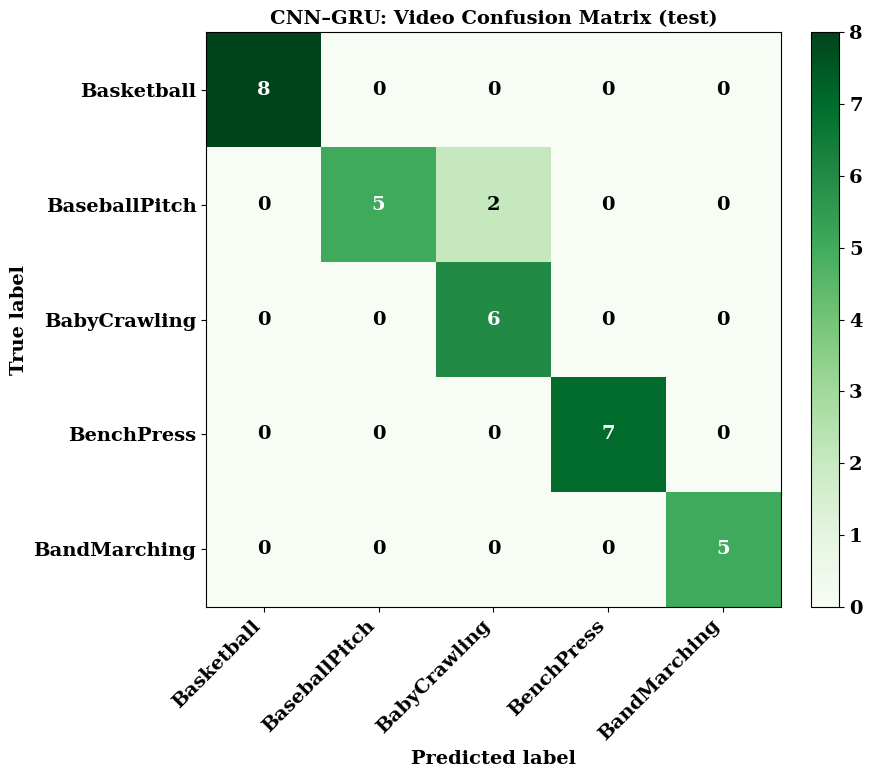

{'best': 'Basketball',
 'best_rec': np.float64(100.0),
 'worst': 'BaseballPitch',
 'worst_err': 2,
 'worst_rec': np.float64(71.42857142857143),
 'pair': ('BaseballPitch', 'BabyCrawling'),
 'pair_ids': (1, 2),
 'pair_n': 2,
 'total_err': 2}

In [26]:
# ===== Plot 9: video confusion matrix =====
plot_confusion(VR["cm"], V_CLASSES, f"CNN–{VBEST}: Video Confusion Matrix (test)", "plot09_video_confusion", cmap="Greens")
cm_inference("plot9", f"CNN–{VBEST}", VR["cm"], V_CLASSES,
             why_fn=lambda a, b: "similar scenes/motion")

## 23. Expected Sequence-to-Sequence Input and Output
Example: `[3, 8, 1, 5]` → `[5, 1, 8, 3]`. At least five test examples are printed below.

In [27]:
# ===== 22/23. Seq2seq data, encoder-decoder model, teacher-forced training, greedy decoding =====
def make_s2s_data(n, L, V, seed, target_fn):
    """n UNIQUE sequences of length L over 1..V (drawn without replacement from the V**L possibilities)."""
    rng = np.random.RandomState(seed)
    ids = rng.choice(V ** L, size=min(n, V ** L), replace=False)
    X = np.stack([(ids // V ** k) % V for k in range(L)][::-1], axis=1) + 1
    return X.astype(np.int32), target_fn(X).astype(np.int32)

def build_s2s(in_len, out_len, vocab, units=S2S_UNITS, emb=S2S_EMB):
    enc_in = keras.Input(shape=(in_len,), dtype="int32", name="encoder_input")
    enc_emb = layers.Embedding(vocab, emb, name="enc_embedding")
    enc_lstm = layers.LSTM(units, return_state=True, name="encoder_lstm")
    _, h, c = enc_lstm(enc_emb(enc_in))                                            # context state (h, C)

    dec_in = keras.Input(shape=(out_len,), dtype="int32", name="decoder_input")
    dec_emb = layers.Embedding(vocab, emb, name="dec_embedding")
    dec_lstm = layers.LSTM(units, return_sequences=True, return_state=True, name="decoder_lstm")
    dense = layers.Dense(vocab, activation="softmax", name="output")
    dec_seq, _, _ = dec_lstm(dec_emb(dec_in), initial_state=[h, c])
    train_model = keras.Model([enc_in, dec_in], dense(dec_seq), name="seq2seq")
    train_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    encoder_model = keras.Model(enc_in, [h, c])                                    # inference: encoder + one-step decoder
    tok = keras.Input(shape=(1,), dtype="int32"); h_in = keras.Input(shape=(units,)); c_in = keras.Input(shape=(units,))
    o, h2, c2 = dec_lstm(dec_emb(tok), initial_state=[h_in, c_in])
    decoder_model = keras.Model([tok, h_in, c_in], [dense(o), h2, c2])
    return train_model, encoder_model, decoder_model

def greedy_decode(enc_m, dec_m, X, out_len):
    h, c = enc_m.predict(X, batch_size=1024, verbose=0)
    tok, outs = np.zeros((len(X), 1), np.int32), []                                # start with <start> = 0
    for _ in range(out_len):
        p, h, c = dec_m.predict([tok, h, c], batch_size=1024, verbose=0)
        tok = p[:, -1].argmax(-1).reshape(-1, 1).astype(np.int32)                  # feed back own prediction
        outs.append(tok[:, 0])
    return np.stack(outs, 1)

def run_seq2seq(in_len=S2S_LEN, out_len=S2S_LEN, target_fn=lambda X: X[:, ::-1], epochs=S2S_EPOCHS, n=S2S_N, verbose_every=10):
    set_seed()
    X, Y = make_s2s_data(n, in_len, S2S_MAX_INT, SEED, target_fn)
    i_tr, i_te = train_test_split(np.arange(len(X)), test_size=0.15, random_state=SEED)
    i_tr, i_va = train_test_split(i_tr, test_size=0.15 / 0.85, random_state=SEED)
    dec_in = lambda Yy: np.concatenate([np.zeros((len(Yy), 1), np.int32), Yy[:, :-1]], axis=1)   # teacher forcing: <start>, y1..y_{L-1}
    tm, em, dm = build_s2s(in_len, out_len, S2S_MAX_INT + 1)
    rb = RestoreBest(); t0 = time.perf_counter()
    h = tm.fit([X[i_tr], dec_in(Y[i_tr])], Y[i_tr], validation_data=([X[i_va], dec_in(Y[i_va])], Y[i_va]),
               epochs=epochs, batch_size=S2S_BATCH, callbacks=[rb, EpochPrinter(verbose_every)], verbose=0).history
    tt = time.perf_counter() - t0
    pred = greedy_decode(em, dm, X[i_te], out_len)
    tok_ok = pred == Y[i_te]
    return dict(model=tm, history=h, best_epoch=rb.epoch, params=count_params(tm), train_time=tt,
                X_te=X[i_te], Y_te=Y[i_te], pred=pred, n_train=len(i_tr), n_val=len(i_va),
                token_acc=tok_ok.mean() * 100, seq_acc=tok_ok.all(axis=1).mean() * 100, pos_acc=tok_ok.mean(axis=0) * 100,
                train_loss=h["loss"][rb.epoch - 1], val_loss=h["val_loss"][rb.epoch - 1])

S2S = run_seq2seq()
S2S["model"].summary()
print(f"\nUnique sequences: train {S2S['n_train']} / val {S2S['n_val']} / test {len(S2S['X_te'])}")

   epoch   1 | loss 2.0034  acc  25.0% | val_loss 1.6154  val_acc  37.7%
   epoch  10 | loss 0.0164  acc 100.0% | val_loss 0.0150  val_acc 100.0%
   epoch  20 | loss 0.0033  acc 100.0% | val_loss 0.0038  val_acc 100.0%
   epoch  30 | loss 0.0014  acc 100.0% | val_loss 0.0016  val_acc 100.0%
   epoch  40 | loss 0.0007  acc 100.0% | val_loss 0.0009  val_acc 100.0%
   epoch  50 | loss 0.0004  acc 100.0% | val_loss 0.0006  val_acc 100.0%
   epoch  60 | loss 0.0003  acc 100.0% | val_loss 0.0004  val_acc 100.0%


Model: "seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 6, 32)     │        320 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 1, 32)     │        320 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     82,432 │ enc_embedding[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 128),  │     82,432 │ dec_embedding[0]… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1, 10)     │      1,290 │ decoder_lstm[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,384 (1.91 MB)

 Trainable params: 166,794 (651.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 333,590 (1.27 MB)


Unique sequences: train 8399 / val 1801 / test 1800


In [28]:
# ===== 23. Test examples: input vs expected vs predicted =====
ex_idx = list(np.random.RandomState(SEED).choice(len(S2S["X_te"]), 5, replace=False))
wrong = [i for i in np.where(~(S2S["pred"] == S2S["Y_te"]).all(axis=1))[0] if i not in ex_idx][:3]     # a few failures for interest
rows = []
for k, i in enumerate(ex_idx + wrong, 1):
    rows.append({"Sample": k if i in ex_idx else f"{k} (error case)",
                 "Input Sequence": list(map(int, S2S["X_te"][i])), "Expected Output": list(map(int, S2S["Y_te"][i])),
                 "Predicted Output": list(map(int, S2S["pred"][i])), "Correct": "✓" if (S2S["pred"][i] == S2S["Y_te"][i]).all() else "✗"})
s2s_examples = pd.DataFrame(rows).set_index("Sample")
display(s2s_examples); save_table(s2s_examples, "table23_seq2seq_examples")

,Input Sequence,Expected Output,Predicted Output,Correct
Sample,,,,
1,"[7, 9, 9, 1, 2, 8]","[8, 2, 1, 9, 9, 7]","[8, 2, 1, 9, 9, 7]",✓
2,"[3, 4, 9, 8, 4, 6]","[6, 4, 8, 9, 4, 3]","[6, 4, 8, 9, 4, 3]",✓
3,"[8, 9, 9, 9, 4, 2]","[2, 4, 9, 9, 9, 8]","[2, 4, 9, 9, 9, 8]",✓
4,"[2, 2, 8, 6, 6, 9]","[9, 6, 6, 8, 2, 2]","[9, 6, 6, 8, 2, 2]",✓
5,"[9, 5, 4, 5, 6, 5]","[5, 6, 5, 4, 5, 9]","[5, 6, 5, 4, 5, 9]",✓
6 (error case),"[8, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 8]","[1, 1, 1, 1, 1, 9]",✗


[saved] /content/outputs/tables/table23_seq2seq_examples.csv


## 24. Sequence-to-Sequence Evaluation
Token accuracy = correct tokens / total tokens; sequence accuracy = completely correct sequences / total sequences. Both are computed on the unseen **test** sequences with autoregressive (greedy) decoding. Training / validation loss are taken at the best-validation epoch.

,Value
Token accuracy,99.99 %
Sequence accuracy,99.94 %
Training loss,0.0003
Validation loss,0.0004
Parameters,"166,794"
Training time,44.9 s


[saved] /content/outputs/tables/table24_seq2seq_metrics.csv
[saved] /content/outputs/plots/plot10_seq2seq_loss_and_accuracy.png


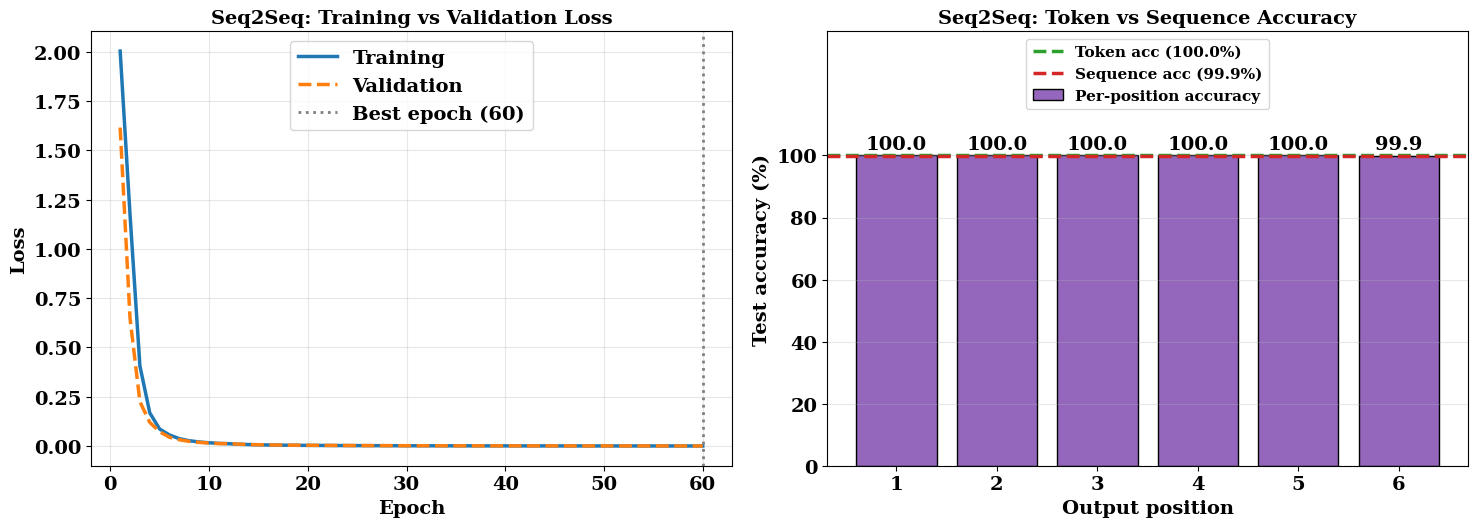

In [29]:
# ===== 24. Metrics, loss curves and per-position accuracy =====
s2s_tbl = pd.DataFrame({"Value": [f"{S2S['token_acc']:.2f} %", f"{S2S['seq_acc']:.2f} %", f"{S2S['train_loss']:.4f}", f"{S2S['val_loss']:.4f}",
                                  f"{S2S['params']:,}", f"{S2S['train_time']:.1f} s"]},
                        index=["Token accuracy", "Sequence accuracy", "Training loss", "Validation loss", "Parameters", "Training time"])
display(s2s_tbl); save_table(s2s_tbl, "table24_seq2seq_metrics")

h = S2S["history"]; ep = np.arange(1, len(h["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(ep, h["loss"], color="tab:blue", lw=2.5, label="Training"); axes[0].plot(ep, h["val_loss"], color="tab:orange", lw=2.5, ls="--", label="Validation")
axes[0].axvline(S2S["best_epoch"], color="gray", ls=":", lw=2, label=f"Best epoch ({S2S['best_epoch']})")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Seq2Seq: Training vs Validation Loss"); axes[0].grid(alpha=0.3); axes[0].legend()
pos = np.arange(1, S2S_LEN + 1)
bars = axes[1].bar(pos, S2S["pos_acc"], color="tab:purple", edgecolor="black", label="Per-position accuracy")
axes[1].bar_label(bars, fmt="%.1f", padding=2)
axes[1].axhline(S2S["token_acc"], color="tab:green", ls="--", lw=2.5, label=f"Token acc ({S2S['token_acc']:.1f}%)")
axes[1].axhline(S2S["seq_acc"], color="tab:red", ls="--", lw=2.5, label=f"Sequence acc ({S2S['seq_acc']:.1f}%)")
axes[1].set_xlabel("Output position"); axes[1].set_ylabel("Test accuracy (%)"); axes[1].set_ylim(0, 140)
axes[1].set_title("Seq2Seq: Token vs Sequence Accuracy"); axes[1].set_xticks(pos); axes[1].set_yticks(range(0, 101, 20)); axes[1].grid(axis="y", alpha=0.3); axes[1].legend(loc="upper center", ncol=1, fontsize=11)
fig.tight_layout(); save_fig(fig, "plot10_seq2seq_loss_and_accuracy"); plt.show()

p = S2S["token_acc"] / 100; indep = p ** S2S_LEN * 100
inference("seq2seq_loss",
    f"Best epoch {S2S['best_epoch']}/{len(ep)}: train loss {S2S['train_loss']:.3f}, val loss {S2S['val_loss']:.3f} (teacher forcing: true previous tokens as input).",
    f"At test time the decoder feeds back its own output: token accuracy {S2S['token_acc']:.1f}% vs sequence accuracy {S2S['seq_acc']:.1f}%.")
inference("seq2seq_token_vs_seq",
    f"One wrong token spoils the whole sequence: token acc {S2S['token_acc']:.1f}% → ≈{indep:.1f}% if independent (observed {S2S['seq_acc']:.1f}%).",
    f"Accuracy by output position: {S2S['pos_acc'].min():.0f}–{S2S['pos_acc'].max():.0f}% (position {int(S2S['pos_acc'].argmin())+1} hardest); a wrong token is fed back.")

## 25. Consolidated Results

In [30]:
# ===== 25. Consolidated tables =====
VB = VIDEO_RES[VBEST]
cons = pd.DataFrame(
    [[RESULTS[k]["accuracy"], RESULTS[k]["precision"], RESULTS[k]["recall"], RESULTS[k]["f1"], f"{RESULTS[k]['params']:,}"] for k in MODELS] +
    [[VB["accuracy"], VB["precision"], VB["recall"], VB["f1"], f"{VB['params']:,}"]],
    columns=["Accuracy (%)", "Precision (%)", "Recall (%)", "F1 (%)", "Parameters"],
    index=["RNN", "LSTM", "GRU", f"CNN–{VBEST} (video)"]).round(2)
cons.index.name = "Model"
print("Sequence classification (HAR, macro-averaged, test set) + video classification (UCF101 subset, test videos)")
display(cons); save_table(cons, "table25_consolidated")

print("\nSequence-to-sequence (reversal task, test set)")
display(s2s_tbl.T); save_table(s2s_tbl.T, "table25_seq2seq")

Sequence classification (HAR, macro-averaged, test set) + video classification (UCF101 subset, test videos)


,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
Model,,,,,
RNN,72.16,72.80,74.42,73.03,"1,974"
LSTM,94.86,95.45,94.93,94.84,"6,006"
GRU,98.29,98.42,98.23,98.29,"4,758"
CNN–GRU (video),93.94,95.00,94.29,93.81,"127,365"


[saved] /content/outputs/tables/table25_consolidated.csv

Sequence-to-sequence (reversal task, test set)


,Token accuracy,Sequence accuracy,Training loss,Validation loss,Parameters,Training time
Value,99.99 %,99.94 %,0.0003,0.0004,"166,794",44.9 s


[saved] /content/outputs/tables/table25_seq2seq.csv


## 26. Required Inferences

In [31]:
# ===== 26. Inference checklist =====
MANDATORY = [("Temporal pattern observed in the sensor signals", "plot1"),
             ("Convergence behaviour of RNN", "loss_RNN"), ("Convergence behaviour of LSTM", "loss_LSTM"), ("Convergence behaviour of GRU", "loss_GRU"),
             ("Evidence of overfitting / underfitting", "acc_RNN"),
             ("Activity-wise errors from the confusion matrix", "cm_RNN"), ("Effect of sequence length", "plot6"),
             ("Parameter and computational differences among RNN / LSTM / GRU", "plot5"),
             ("Role of the CNN in video understanding", "plot7"), ("Role of the recurrent model in temporal modelling", "plot7"),
             ("Token accuracy vs sequence accuracy in seq2seq", "seq2seq_token_vs_seq")]
logged = {tag for tag, _ in INFERENCE_LOG}
for title, tag in MANDATORY:
    print(("[OK]      " if tag in logged else "[MISSING] ") + title)

with open(OUT_DIR / "inferences.txt", "w", encoding="utf-8") as f:
    for tag, text in INFERENCE_LOG:
        f.write(f"[{tag}] {text}\n\n")
print(f"\n{len(INFERENCE_LOG)} inferences saved to {OUT_DIR / 'inferences.txt'}")

[OK]      Temporal pattern observed in the sensor signals
[OK]      Convergence behaviour of RNN
[OK]      Convergence behaviour of LSTM
[OK]      Convergence behaviour of GRU
[OK]      Evidence of overfitting / underfitting
[OK]      Activity-wise errors from the confusion matrix
[OK]      Effect of sequence length
[OK]      Parameter and computational differences among RNN / LSTM / GRU
[OK]      Role of the CNN in video understanding
[OK]      Role of the recurrent model in temporal modelling
[OK]      Token accuracy vs sequence accuracy in seq2seq

22 inferences saved to /content/outputs/inferences.txt


## 27. Discussion Questions

**1. What is a recurrent neural network?** A network with a feedback loop: at each step it combines the current input with a hidden state carried from the previous step, using the same weights at every step, so it can process variable-length sequences.

**2. What information is represented by the hidden state?** A compressed summary of everything seen so far in the sequence (its "memory"), which is passed to the next step and, at the end, to the classifier.

**3. Why is sequence order important?** The meaning lies in the ordering (gait cycles, posture transitions, words in a sentence, motion in a video); shuffling the time steps destroys these patterns although the individual values stay the same.

**4. Feed-forward network vs. RNN.** A feed-forward network maps a fixed-size input to an output with no memory and independent inputs; an RNN reuses its weights over time and has a recurrent connection $h_{t-1}\to h_t$, so its output depends on the whole history.

**5. Backpropagation Through Time.** Unroll the RNN over $T$ steps (a deep network with shared weights), run the forward pass, then backpropagate the loss through every step and sum the weight gradients from all steps.

**6. Why can gradients vanish during BPTT?** The gradient reaching step $t-k$ contains a product of $k$ Jacobians $\operatorname{diag}(1-h^2)W_h$; when their norm is below 1 (saturating tanh derivatives ≤ 1, small $W_h$) the product shrinks exponentially with $k$.

**7. Why can gradients explode?** If the norm of those Jacobians is above 1 (large $W_h$), the product grows exponentially, causing huge updates and unstable training; gradient clipping is the usual remedy.

**8. What are long-term dependencies?** Situations where the output at a late time step depends on information from many steps earlier; plain RNNs struggle to learn them because of vanishing gradients.

**9. Role of the LSTM cell state.** It is a separate memory line updated additively ($C_t=f_tC_{t-1}+i_t\tilde C_t$), so information and gradients can flow across many steps almost unchanged.

**10. Forget, input and output gates.** Forget gate: how much of the old cell state to keep. Input gate: how much of the new candidate to write. Output gate: how much of the (squashed) cell state to expose as $h_t$.

**11. Reset and update gates in GRU.** Reset gate $r_t$: how much of the previous state is used when forming the candidate. Update gate $z_t$: how much of the state is replaced by the candidate versus kept.

**12. Compare LSTM and GRU.** LSTM: separate cell and hidden states, 3 gates, more parameters (4 weight blocks). GRU: one state, 2 gates, fewer parameters (3 blocks), usually faster; accuracy is often similar, and which wins depends on the data (see the tables above).

**13. Why does GRU use a simpler gating mechanism?** It merges the forget and input gates into one update gate and merges cell and hidden state, giving a cheaper unit that keeps most of the long-term-memory benefit.

**14. Why compare with the same experimental settings?** So that differences in results can be attributed to the recurrent cell itself and not to different data splits, optimisers, learning rates, epochs or seeds (a controlled experiment).

**15. What does the confusion matrix reveal that accuracy alone does not?** Which classes are confused with which, class-wise recall/precision and systematic error patterns (e.g. Sitting↔Standing), which a single number hides, especially with class imbalance.

**16. Why report macro F1?** It averages the per-class F1 with equal weight, so poor performance on a minority or difficult class is not hidden by frequent classes, and it balances precision and recall.

**17. Significance of sequence length.** It sets how much temporal context the model sees, and it also sets the BPTT depth and computational cost: too short misses the pattern, too long increases cost and gradient problems.

**18. Why can a CNN be a feature extractor for video?** A CNN pretrained on a large image dataset (ImageNet) already encodes generic visual concepts; with the classification head removed it turns every frame into a compact vector without training a CNN from scratch on a small video set.

**19. What information does the CNN extract?** Spatial information in a single frame: edges, textures, objects, body shape/pose and scene context.

**20. What information does the recurrent network learn?** Temporal information across frames: how the spatial features change (motion, repetition, order of events), which decides the action.

**21. Why are CNN features arranged as a sequence?** Frames are ordered in time; stacking the per-frame vectors in order gives a $(T,D)$ sequence, the input format LSTM/GRU expect, so temporal relations can be modelled.

**22. Encoder and decoder.** The encoder reads the input sequence and compresses it into a context (its final state); the decoder is initialised with this context and generates the output sequence one token at a time, feeding back the previous token.

**23. What is teacher forcing?** During training the decoder receives the ground-truth previous token instead of its own previous prediction; this speeds up and stabilises training but creates a train/test mismatch (exposure bias) because at test time it must use its own outputs.

**24. Token accuracy vs. sequence accuracy.** Token accuracy = fraction of individual tokens right; sequence accuracy = fraction of sequences with *all* tokens right. The second is always ≤ the first, since one wrong token invalidates a whole sequence.

**25. Why must the test set remain untouched during model selection?** If it influences choices (epochs, hyperparameters, architecture), the reported score becomes optimistically biased; selection must use the validation set so that the test set gives an unbiased estimate of generalisation.

## 28. Additional Exercises

In [32]:
# ===== 28. Exercises that reuse existing results (always run) =====
cost = pd.DataFrame({f"{k} time (s)": [SEQ_RESULTS[T][k]["train_time"] for T in SEQ_LENGTHS] for k in MODELS},
                    index=pd.Index(SEQ_LENGTHS, name="Sequence Length")).round(1)
print("Ex. 5 - training time vs sequence length"); display(cost); save_table(cost, "ex5_time_vs_sequence_length")

vt = pd.DataFrame({f"CNN–{k}": [VIDEO_RES[k]["accuracy"], VIDEO_RES[k]["f1"], VIDEO_RES[k]["params"], VIDEO_RES[k]["train_time"]] for k in ("LSTM", "GRU")},
                  index=["Test accuracy (%)", "Macro F1 (%)", "Parameters", "Training time (s)"]).round(2)
print("\nEx. 6 - video: LSTM vs GRU on identical CNN features"); display(vt); save_table(vt, "ex6_video_lstm_vs_gru")

Ex. 5 - training time vs sequence length


,RNN time (s),LSTM time (s),GRU time (s)
Sequence Length,,,
32,20.5,21.6,19.6
64,21.8,21.3,21.0
128,30.6,25.5,26.3


[saved] /content/outputs/tables/ex5_time_vs_sequence_length.csv

Ex. 6 - video: LSTM vs GRU on identical CNN features


,CNN–LSTM,CNN–GRU
Test accuracy (%),93.94,93.94
Macro F1 (%),93.81,93.81
Parameters,169285.00,127365.00
Training time (s),19.87,9.69


[saved] /content/outputs/tables/ex6_video_lstm_vs_gru.csv



--- LSTM-16u-1L
   epoch   1 | loss 1.6890  acc  34.6% | val_loss 1.5197  val_acc  41.5%
   epoch  10 | loss 0.3024  acc  89.0% | val_loss 0.2930  val_acc  90.2%
   epoch  20 | loss 0.1716  acc  93.8% | val_loss 0.3281  val_acc  90.9%
   epoch  30 | loss 0.1372  acc  94.6% | val_loss 0.1673  val_acc  95.1%

--- LSTM-64u-1L
   epoch   1 | loss 1.3952  acc  44.7% | val_loss 0.9724  val_acc  66.1%
   epoch  10 | loss 0.1545  acc  94.0% | val_loss 0.1468  val_acc  97.7%
   epoch  20 | loss 0.1209  acc  95.2% | val_loss 0.1138  val_acc  97.2%
   epoch  30 | loss 0.1154  acc  95.0% | val_loss 0.1112  val_acc  97.2%

--- GRU-16u-1L
   epoch   1 | loss 1.7549  acc  27.5% | val_loss 1.6069  val_acc  46.4%
   epoch  10 | loss 0.4194  acc  84.1% | val_loss 0.3188  val_acc  86.5%
   epoch  20 | loss 0.1631  acc  93.9% | val_loss 0.1302  val_acc  95.9%
   epoch  30 | loss 0.1387  acc  94.4% | val_loss 0.1432  val_acc  95.3%

--- GRU-64u-1L
   epoch   1 | loss 1.5118  acc  36.2% | val_loss 1.3201  

,Units,Layers,Bidirectional,Accuracy (%),Macro F1 (%),Parameters,Time (s)
Model,,,,,,,
BiLSTM-32u-1L,32,1,True,94.22,94.21,11894,37.10
GRU-16u-1L,16,1,False,97.22,97.27,1670,25.27
GRU-32u-1L,32,1,False,98.29,98.29,4758,26.32
GRU-32u-2L,32,2,False,98.93,98.90,11094,35.36
GRU-64u-1L,64,1,False,99.14,99.22,15542,24.97
LSTM-16u-1L,16,1,False,97.43,97.42,2038,25.98
LSTM-32u-1L,32,1,False,94.86,94.84,6006,25.46
LSTM-32u-2L,32,2,False,96.79,96.65,14326,35.02
LSTM-64u-1L,64,1,False,96.15,96.02,20086,26.90


[saved] /content/outputs/tables/ex1_3_4_additional.csv
[saved] /content/outputs/plots/plot11_additional_exercises.png


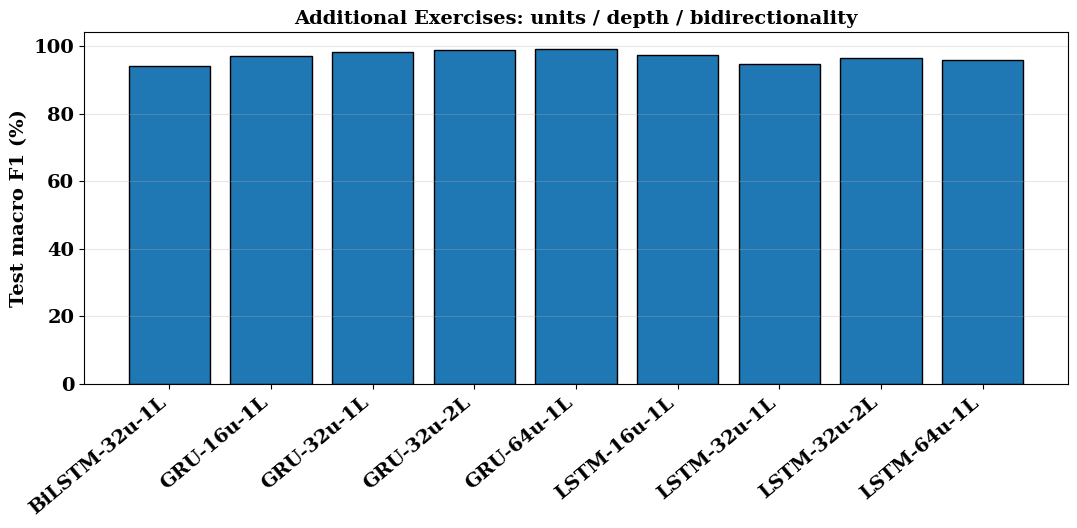

   epoch   1 | loss 1.9477  acc  30.9% | val_loss 1.4279  val_acc  45.5%
   epoch  10 | loss 0.0042  acc 100.0% | val_loss 0.0039  val_acc 100.0%
   epoch  20 | loss 0.0010  acc 100.0% | val_loss 0.0010  val_acc 100.0%
   epoch  30 | loss 0.0004  acc 100.0% | val_loss 0.0004  val_acc 100.0%
   epoch  40 | loss 0.0002  acc 100.0% | val_loss 0.0002  val_acc 100.0%

Ex.7 (input length 6 -> output length 3): token acc 100.0% | sequence acc 100.0%
  [1, 6, 3, 9, 3, 5] -> predicted [5, 3, 9] | expected [5, 3, 9]
  [9, 2, 1, 2, 4, 1] -> predicted [1, 4, 2] | expected [1, 4, 2]
  [8, 1, 1, 5, 8, 9] -> predicted [9, 8, 5] | expected [9, 8, 5]
  [2, 8, 1, 1, 8, 7] -> predicted [7, 8, 1] | expected [7, 8, 1]
  [4, 5, 6, 6, 7, 1] -> predicted [1, 7, 6] | expected [1, 7, 6]


In [33]:
# ===== 28. Exercises 1, 3, 4 and 7 (optional, RUN_ADDITIONAL_EXERCISES) =====
if RUN_ADDITIONAL_EXERCISES:
    extra = []
    # Ex.1: 16 / 32 / 64 units (LSTM and GRU)   Ex.3: two stacked layers   Ex.4: bidirectional vs unidirectional LSTM
    configs = ([("LSTM", u, 1, False) for u in (16, 64)] + [("GRU", u, 1, False) for u in (16, 64)] +
               [("LSTM", UNITS, 2, False), ("GRU", UNITS, 2, False), ("LSTM", UNITS, 1, True)])
    for kind, u, nl, bi in configs:
        tag = f"{'Bi' if bi else ''}{kind}-{u}u-{nl}L"; print("\n---", tag)
        r = train_eval(kind, data, units=u, n_layers=nl, bidirectional=bi, tag=tag, verbose_every=10)
        extra.append(dict(Model=tag, Units=u, Layers=nl, Bidirectional=bi, **{"Accuracy (%)": r["accuracy"], "Macro F1 (%)": r["f1"],
                          "Parameters": r["params"], "Time (s)": r["train_time"]}))
    for k in ("LSTM", "GRU"):                                                          # baseline rows (32 units) from the main run
        extra.append(dict(Model=f"{k}-32u-1L", Units=32, Layers=1, Bidirectional=False, **{"Accuracy (%)": RESULTS[k]["accuracy"],
                          "Macro F1 (%)": RESULTS[k]["f1"], "Parameters": RESULTS[k]["params"], "Time (s)": RESULTS[k]["train_time"]}))
    ex_tbl = pd.DataFrame(extra).sort_values(["Model"]).set_index("Model").round(2)
    display(ex_tbl); save_table(ex_tbl, "ex1_3_4_additional")
    fig, ax = plt.subplots(figsize=(11, 5.5)); labels = ex_tbl.index.tolist()
    ax.bar(np.arange(len(labels)), ex_tbl["Macro F1 (%)"], color="tab:blue", edgecolor="black")
    ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels, rotation=40, ha="right"); ax.set_ylabel("Test macro F1 (%)")
    ax.set_title("Additional Exercises: units / depth / bidirectionality"); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout(); save_fig(fig, "plot11_additional_exercises"); plt.show()
    best_x = ex_tbl["Macro F1 (%)"].idxmax()
    inference("additional", f"Best by test macro-F1: {best_x} ({ex_tbl.loc[best_x, 'Macro F1 (%)']:.1f}%, {int(ex_tbl.loc[best_x, 'Parameters']):,} params).",
              "Extra units, depth or bidirectionality cost parameters and time; keep them only if gains exceed run-to-run noise.")

    # Ex.7: output length differs from input length -> first 3 tokens of the reversed sequence (6 -> 3)
    S2S_DIFF = run_seq2seq(in_len=6, out_len=3, target_fn=lambda X: X[:, ::-1][:, :3], epochs=40)
    print(f"\nEx.7 (input length 6 -> output length 3): token acc {S2S_DIFF['token_acc']:.1f}% | sequence acc {S2S_DIFF['seq_acc']:.1f}%")
    for i in range(5):
        print(f"  {list(map(int, S2S_DIFF['X_te'][i]))} -> predicted {list(map(int, S2S_DIFF['pred'][i]))} | expected {list(map(int, S2S_DIFF['Y_te'][i]))}")
else:
    print("Additional exercises 1, 3, 4, 7 skipped (set RUN_ADDITIONAL_EXERCISES = True in Section 0 to run them).")

## Export — collect all plots and tables

In [34]:
# ===== Export: zip everything for the lab manual =====
print("Saved plots:");  [print("  ", p.name) for p in sorted(PLOT_DIR.glob("*.png"))]
print("Saved tables:"); [print("  ", p.name) for p in sorted(TABLE_DIR.glob("*.csv"))]
zip_base = str(BASE_DIR / "lab6_outputs")
shutil.make_archive(zip_base, "zip", str(OUT_DIR))
print(f"\nEverything zipped to {zip_base}.zip")
if ON_COLAB:
    from google.colab import files
    files.download(zip_base + ".zip")
elif ON_KAGGLE:
    print("On Kaggle: open the 'Output' tab of the notebook (or 'Save Version') to download lab6_outputs.zip and the outputs/ folder.")

Saved plots:
   plot01_sensor_signals.png
   plot02_loss_GRU.png
   plot02_loss_LSTM.png
   plot02_loss_RNN.png
   plot03_accuracy_GRU.png
   plot03_accuracy_LSTM.png
   plot03_accuracy_RNN.png
   plot04_confusion_GRU.png
   plot04_confusion_LSTM.png
   plot04_confusion_RNN.png
   plot05_model_comparison.png
   plot06_sequence_length_vs_f1.png
   plot07_video_sample_frames.png
   plot08_video_training_curves.png
   plot09_video_confusion.png
   plot10_seq2seq_loss_and_accuracy.png
   plot11_additional_exercises.png
Saved tables:
   bptt_numerical_exercise.csv
   class_distribution.csv
   ex1_3_4_additional.csv
   ex5_time_vs_sequence_length.csv
   ex6_video_lstm_vs_gru.csv
   table14_performance.csv
   table16_comparison.csv
   table17_sequence_length.csv
   table23_seq2seq_examples.csv
   table24_seq2seq_metrics.csv
   table25_consolidated.csv
   table25_seq2seq.csv

Everything zipped to /content/lab6_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>